1. Introduction

The emergence of music streaming platforms has transformed the modern music industry by providing large-scale access to listener behavior and detailed musical metadata. Spotify, one of the world’s largest streaming services, offers quantitative descriptions of songs through audio features such as danceability, energy, valence, tempo, loudness, acousticness, etc. These variables provide an opportunity to analyze music using statistical and data science methods (Morris & Powers, 2015).

At the same time, commercial music charts such as the Billboard Hot 100 remain among the most widely recognized indicators of musical success and public popularity. Billboard rankings reflect commercial performance through streaming, radio airplay, and sales data, making them a useful external measure of popularity independent from Spotify’s internal algorithms (Billboard, 2025).

The combination of Spotify audio features and Billboard chart data allows for the investigation of relationships between musical characteristics and commercial success. Understanding these relationships is valuable not only for academic purposes, but also for artists, producers, streaming platforms, and the music industry as a whole.

This project investigates whether specific Spotify audio features are associated with stronger Billboard chart performance. The study follows a standard data workflow consisting of data acquisition, cleaning and consolidation as two types of independent datasets are combined: Two Spotify audio feature datasets and Billboard chart ranking data. Afterwards, the project exposes statistical relationships between musical properties and chart success through exploratory data analysis, visualization, and hypothesis testing. Time of release and genre are also taken into mind as dimensions during the exploratory analysis. Results and discussion follow next, as well as conclusion at the end.




2. Related Work

The analysis of music using quantitative methods has become increasingly common due to the availability of large streaming datasets and advances in data science. Previous research has examined recommendation systems, genre classification, popularity prediction, and emotional analysis of music.

Spotify audio features have frequently been used in machine learning and statistical studies because they provide numerical representations of perceptual musical properties. Features such as danceability, energy, and valence are commonly analyzed to identify genre differences and listener preferences (Schedl, Gómez, & Urbano, 2014).

Several studies suggest that commercially successful songs share common characteristics. Popular tracks are often associated with higher loudness, stronger rhythmic structure, and higher danceability values. Research on musical hit prediction has shown that audio features can be significant predictors of commercial success (Pachet & Roy, 2008; Herremans, Martens, & Sörensen, 2014).

Other research has investigated temporal trends in music, including the so-called “loudness war” and changes in musical complexity over time. Serrà et al. (2012) observed increasing loudness and homogenization in modern popular music, suggesting that commercial pressures may influence production styles.

Billboard rankings have also been used as indicators of commercial success in studies involving predictive analytics and trend forecasting. Dhanaraj and Logan (2005) explored the prediction of hit songs using audio and metadata features, while more recent studies have investigated streaming-era popularity prediction using large-scale music datasets.

This project differs from many existing studies by emphasizing interpretability, statistical hypothesis testing, exploratory visualization, and reproducible data-processing workflows rather than solely predictive modeling.

3. Data

   3.1 Data Extraction

The datasets used in this project were obtained from publicly available online repositories and consolidated into a unified analytical dataset.

Spotify audio-feature data was collected from a publicly available Kaggle dataset containing approximately 100,000 songs across multiple genres and release periods. The dataset includes numerical audio descriptors generated by Spotify’s internal music-analysis algorithms, including danceability, energy, loudness, valence, tempo, acousticness, speechiness, and popularity scores.

Billboard chart data was obtained from a historical Billboard Hot 100 dataset containing weekly chart rankings, peak chart positions, and chart duration information. The dataset provides an external measure of commercial song success independent from Spotify’s platform-specific popularity metric.

The extraction process involved downloading both datasets in CSV format and loading them into pandas DataFrames using Python. Since the datasets originated from independent sources, preprocessing and consolidation were required before analysis. Song titles and artist names were normalized by converting text to lowercase, removing punctuation, and eliminating non-essential suffixes such as “remastered” or “live”.

After normalization, the datasets were merged using combinations of song titles and artist names. Duplicate entries and incomplete observations were removed in order to improve consistency and reduce matching errors.

The resulting consolidated dataset contained both Spotify audio characteristics and Billboard chart-performance indicators, enabling comparative statistical analysis between musical properties and commercial success.

The project uses two independent datasets.

The first dataset contains Spotify audio features and song metadata. Variables include song title, artist, genre, danceability, energy, valence, loudness, tempo, acousticness, speechiness, instrumentalness, liveness, and Spotify popularity score. Spotify audio features represent numerical descriptions of musical characteristics generated using Spotify’s internal analysis algorithms (Spotify for Developers, 2025). The dataset contains approximately 100,000 songs from multiple genres and release periods.

The second dataset contains Billboard chart performance information. Variables include song title, artist, chart rank, peak position, weeks on chart, and chart date. These variables provide an external measure of commercial success independent from Spotify’s internal popularity metric.

The datasets are merged using normalized song titles and artist names. Several preprocessing steps are required before consolidation, including the removal of duplicate records, standardization of text formatting, removal of remastered or live-edition suffixes, handling missing values, and datatype correction. This merging process is one of the most important stages of the project because inconsistencies between datasets may introduce matching errors.

Several Spotify audio features displayed skewed distributions, particularly instrumentalness, speechiness, liveness, and acousticness. This is expected because most commercially released tracks are vocal-based studio recordings, resulting in many low values for instrumentalness and liveness. Because some variables were not normally distributed, exploratory visualizations were supported with correlation-based and non-parametric statistical approaches where appropriate.

3.2 Adding Chart Success Score

In order to obtain a more comprehensive measure of commercial success, a derived metric called the Chart Success Score (CSS) was introduced. Billboard chart datasets contain several indicators of success, including peak chart position and total weeks spent on the chart. However, each variable individually captures only a single dimension of popularity.

For example, some songs may achieve a very high chart position for a short period of time, while others may remain on the charts for many weeks without reaching the top positions. To address this limitation, the Chart Success Score combines both ranking performance and chart longevity into a single numerical measure.

The score is defined as:

CSS=
PeakRank
1
	​

+log(WeeksOnChart+1)

where:

PeakRank represents the highest Billboard position achieved by a song,
WeeksOnChart represents the total number of weeks spent on the Billboard Hot 100.

The reciprocal of peak rank rewards songs achieving stronger chart positions, while the logarithmic component captures chart longevity while reducing the influence of extreme outliers. The logarithmic transformation also reflects diminishing returns in long-term chart presence.

The resulting metric provides a more balanced representation of commercial success compared to using peak rank or chart duration independently.


Chart Success Score Normalization

After computing the Chart Success Score (CSS), the values were normalized using z-score normalization in order to improve comparability between variables and reduce scale-related effects during statistical analysis.

The normalized Chart Success Score is defined as:

CSS
norm
	​

=
σ
CSS
	​

CSS−μ
CSS
	​

	​


where:

CSS is the original Chart Success Score,
μ
CSS
	​

 is the mean value of the Chart Success Score across all observations,
σ
CSS
	​

 is the standard deviation of the Chart Success Score.

Z-score normalization transforms the distribution to have:

mean equal to 0,
standard deviation equal to 1.

This normalization procedure provides several advantages. First, it allows variables measured on different numerical scales to be compared more directly. Second, normalization reduces the influence of extreme values and improves interpretability during correlation and regression analysis. Finally, standardized variables simplify visualization and statistical comparison between groups.

Positive normalized values indicate songs performing above the dataset average in terms of commercial success, while negative values indicate below-average performance.

The normalized Chart Success Score was subsequently used as the primary dependent variable during correlation analysis, hypothesis testing, and exploratory visualization.

4. Limitations

Several limitations affect the analysis presented in this study.

First, Spotify audio features are generated by proprietary algorithms whose exact implementation is not publicly available. As a result, some variables may contain hidden assumptions or biases that cannot be fully evaluated.

Second, Billboard rankings are influenced by multiple external factors beyond musical structure itself. Marketing campaigns, artist popularity, radio promotion, social media trends, and seasonal listening behavior may all influence chart success (Datta, Knox, & Bronnenberg, 2018).

Another limitation concerns dataset consolidation. Since the datasets are merged using song titles and artist names, mismatches may occur due to alternative spellings, featured artists, remastered editions, or regional naming conventions.

The analysis is also observational rather than experimental. Consequently, even when statistically significant relationships are identified, correlation does not imply causation. A strong relationship between danceability and chart success, for example, does not necessarily mean that danceability directly causes popularity.

Finally, some genres may be underrepresented in the datasets, which could affect comparisons between musical categories.

In [ ]:
5. Exploratory Data Analysis

In [ ]:
The goal is to understand how Spotify audio features are distributed, how charted and non-charted songs differ, how musical characteristics change across decades, and how genre is related to both musical style and Billboard performance.

The analysis uses several complementary visualizations. Distribution plots are used to inspect the shape and skewness of variables. Standardized bar charts and line charts compare features that originally have different scales. Correlation heatmaps are used to examine whether features are associated with either Billboard chart success or charted status. Throughout the exploratory section, the results should be interpreted as associations rather than causal effects.

5.1 Standardized mean audio features by chart status

This graph compares charted and non-charted songs across the main Spotify audio features. Because the features have different measurement scales, the values are standardized as z-scores. A value above zero means that the group is above the overall dataset average for that feature, while a value below zero means that the group is below the overall average.

This visualization is useful because it provides a quick overview of which musical characteristics tend to be higher or lower for charted songs compared with non-charted songs. The graph does not prove that a feature causes chart success, but it helps identify patterns that can be tested statistically later.

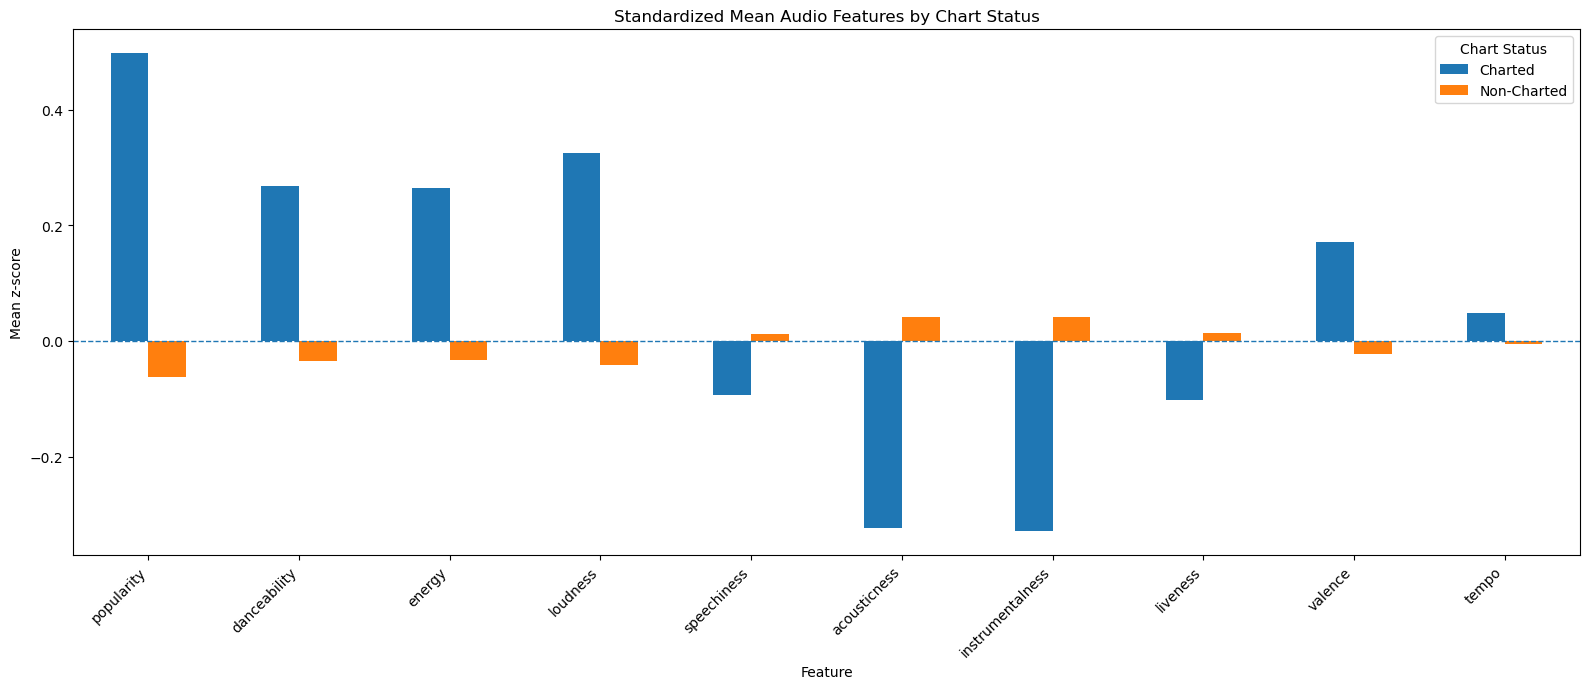

In [152]:




z_means_by_chart_status.plot(
kind="bar",
figsize=(16, 7)
)

plt.title("Standardized Mean Audio Features by Chart Status")
plt.xlabel("Feature")
plt.ylabel("Mean z-score")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend(title="Chart Status")
plt.tight_layout()
plt.show()





In [ ]:
##5.2 Standardized audio-feature trends by decade

In [ ]:
These two line graphs show how average Spotify audio features change across decades. The values are standardized, so the y-axis represents the average z-score for each feature in each decade. The horizontal zero line represents the overall dataset average.

The first graph focuses on broader production and popularity-related characteristics: popularity, danceability, energy, loudness, and tempo. The second graph focuses on more specific musical texture characteristics: speechiness, acousticness, instrumentalness, liveness, and valence.

These graphs are useful for identifying long-term changes in recorded music. For example, they can show whether later decades contain louder, more energetic, less acoustic, or more danceable tracks than earlier decades.

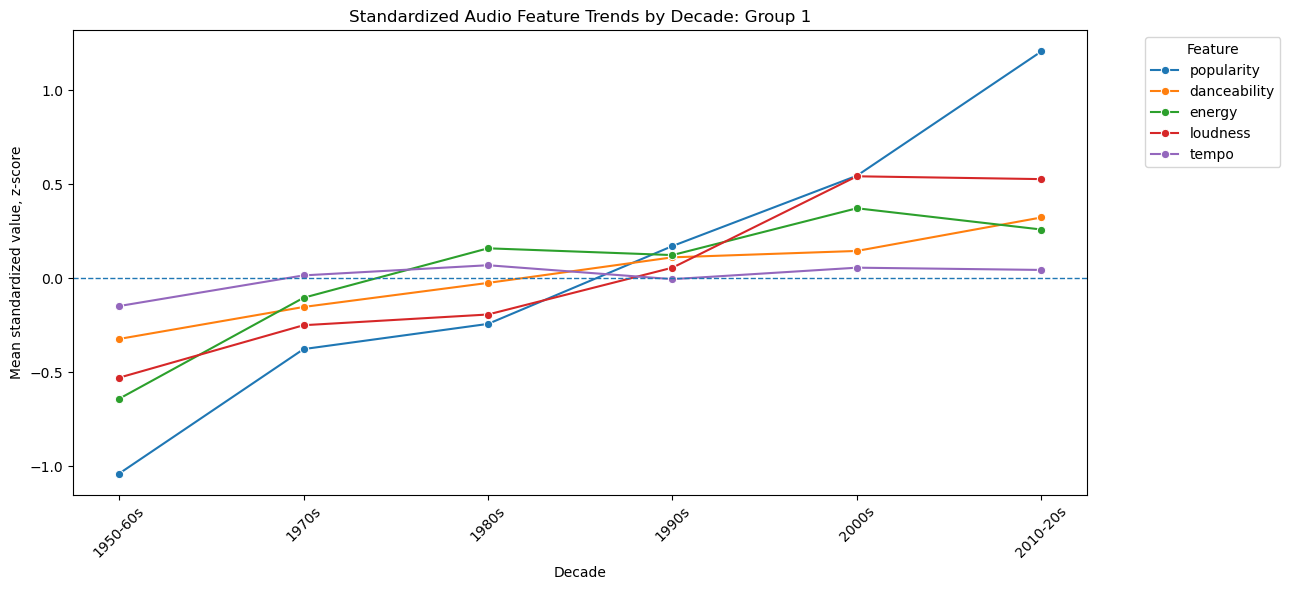

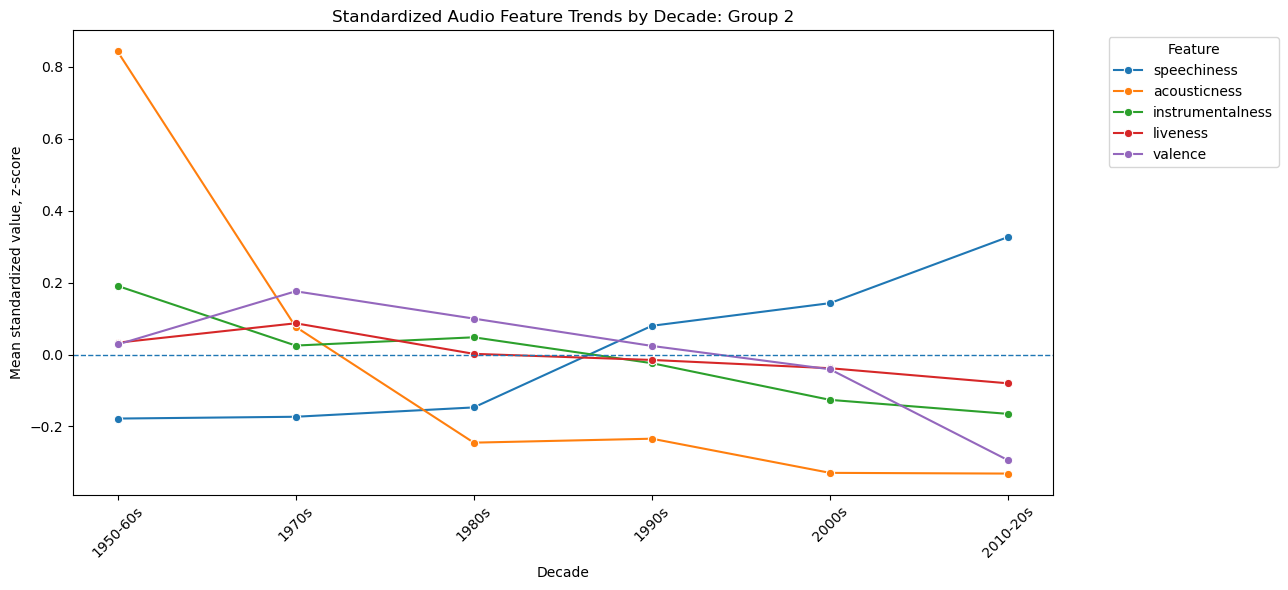

In [218]:
feature_group_1 = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "tempo"
]

feature_group_2 = [
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]


group_1_trends = decade_feature_means_z[feature_group_1]

group_1_long = (
    group_1_trends
    .reset_index()
    .melt(
        id_vars="decade_label",
        var_name="feature",
        value_name="mean_z_score"
    )
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=group_1_long,
    x="decade_label",
    y="mean_z_score",
    hue="feature",
    marker="o"
)

plt.title("Standardized Audio Feature Trends by Decade: Group 1")
plt.xlabel("Decade")
plt.ylabel("Mean standardized value, z-score")
plt.xticks(rotation=45)
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()





group_2_trends = decade_feature_means_z[feature_group_2]

group_2_long = (
    group_2_trends
    .reset_index()
    .melt(
        id_vars="decade_label",
        var_name="feature",
        value_name="mean_z_score"
    )
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=group_2_long,
    x="decade_label",
    y="mean_z_score",
    hue="feature",
    marker="o"
)

plt.title("Standardized Audio Feature Trends by Decade: Group 2")
plt.xlabel("Decade")
plt.ylabel("Mean standardized value, z-score")
plt.xticks(rotation=45)
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

In [ ]:
5.3 Distribution of Spotify audio features

In [ ]:
These histograms show the distribution of each Spotify audio feature in the full dataset. This step is important because it shows whether the variables are approximately balanced, concentrated around a narrow range, or highly skewed.

Some skewness is expected in music data. For example, instrumentalness is often concentrated near zero because most popular songs contain vocals. Speechiness and liveness can also be skewed because most tracks are studio recordings and are primarily sung rather than spoken. Observing these distributions helps choose suitable statistical methods later, such as Spearman correlation when variables are not normally distributed.

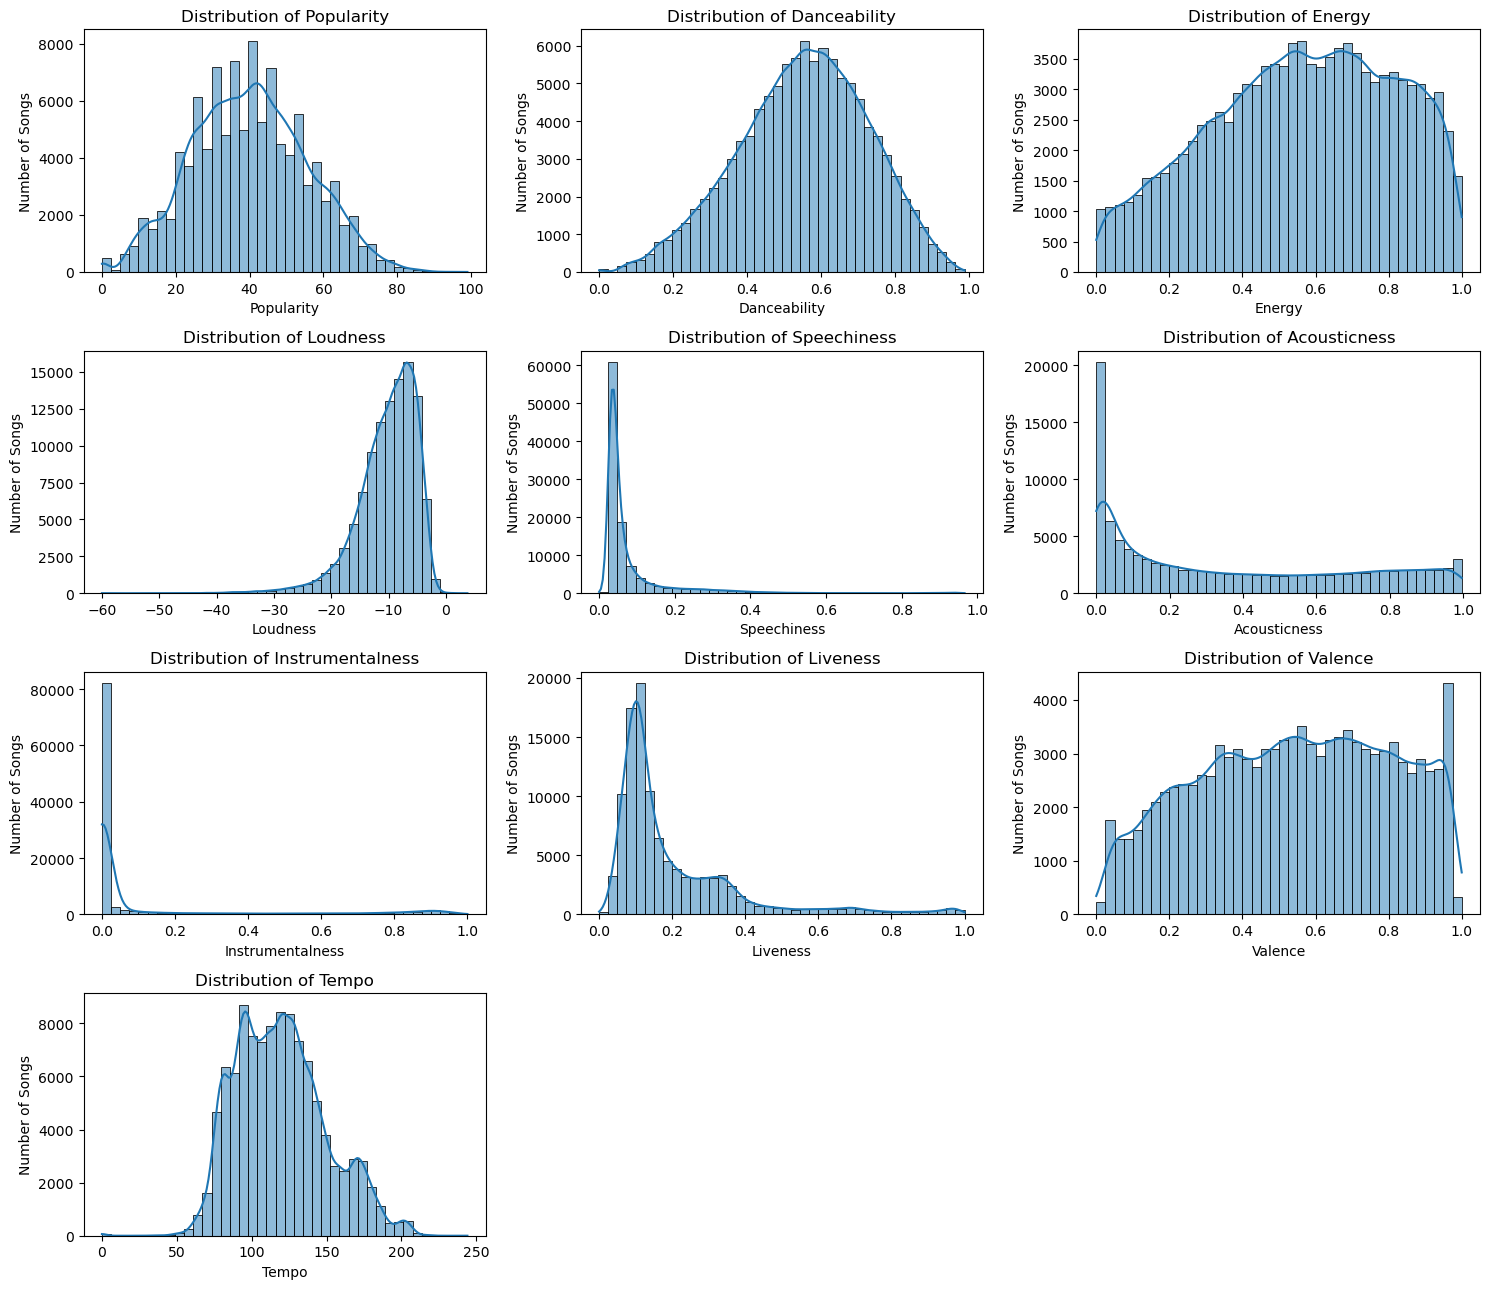

In [268]:
audio_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(15, 13)
)

axes = axes.flatten()

for i, feature in enumerate(audio_features):
    sns.histplot(
        data=final_df,
        x=feature,
        bins=40,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {feature.capitalize()}")
    axes[i].set_xlabel(feature.capitalize())
    axes[i].set_ylabel("Number of Songs")

# Hide unused empty subplots
for j in range(len(audio_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
5.4 Audio features as indicators of charted status by decade

In [ ]:
This heatmap examines whether each Spotify audio feature is associated with a track being charted rather than non-charted within each decade.

The analysis uses charted_binary, where:

1 = Charted
0 = Non-Charted

Because the outcome variable is binary, the graph uses point-biserial correlation. This measures whether higher values of a numerical feature, such as danceability, energy, or loudness, are associated with a higher probability of a track being charted.

Positive values mean that higher values of that feature are more common among charted tracks in that decade. Negative values mean that higher values of that feature are more common among non-charted tracks. Values close to zero suggest that the feature does not strongly distinguish charted from non-charted tracks for that decade.

The stars show statistical significance:

*   p < 0.05
**  p < 0.01
*** p < 0.001

In simple words, this graph helps answer the question:

Did certain musical characteristics make a song more likely to appear on Billboard in specific decades?

For example, if danceability has a positive and statistically significant value in the 1980s, this suggests that more danceable songs were more likely to be charted in that decade. If instrumentalness has a negative value, this suggests that more instrumental tracks were less likely to become charted during that period.

This analysis is useful because the relationship between audio features and chart success may change over time. A feature that helps distinguish charted songs in one decade may not be important in another decade.

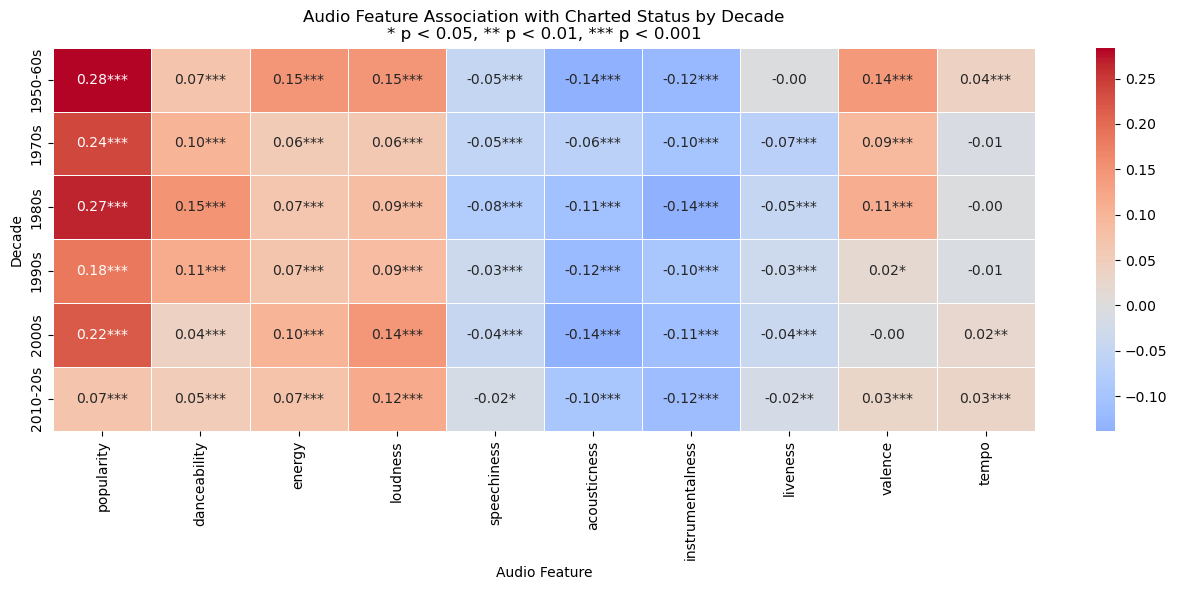

In [252]:
from scipy.stats import pointbiserialr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_tracks_per_decade = 1000


decade_order = [
    "1950-60s",
    "1970s",
    "1980s",
    "1990s",
    "2000s",
    "2010-20s"
]

final_df["decade_label"] = final_df["decade_label"].astype(str)

final_df["decade_label"] = pd.Categorical(
    final_df["decade_label"],
    categories=decade_order,
    ordered=True
)

valid_decades = (
    final_df["decade_label"]
    .value_counts()
    .loc[lambda x: x >= min_tracks_per_decade]
    .index
)

decade_df = final_df[
    final_df["decade_label"].isin(valid_decades)
].copy()

decade_feature_chart_corr = pd.DataFrame(
    index=decade_order,
    columns=selected_features,
    dtype=float
)

decade_feature_chart_pvalues = pd.DataFrame(
    index=decade_order,
    columns=selected_features,
    dtype=float
)

for decade in decade_order:
    decade_data = decade_df[
        decade_df["decade_label"] == decade
    ].copy()

    # Skip decades with too few records
    if len(decade_data) < min_tracks_per_decade:
        continue

    for feature in selected_features:
        temp_df = decade_data[[feature, "charted_binary"]].dropna()

        # Need both charted and non-charted tracks present
        if (
            len(temp_df) >= min_tracks_per_decade and
            temp_df["charted_binary"].nunique() == 2
        ):
            corr, p_value = pointbiserialr(
                temp_df["charted_binary"],
                temp_df[feature]
            )

            decade_feature_chart_corr.loc[decade, feature] = corr
            decade_feature_chart_pvalues.loc[decade, feature] = p_value

decade_feature_chart_corr = decade_feature_chart_corr.dropna(how="all").round(3)
decade_feature_chart_pvalues = decade_feature_chart_pvalues.dropna(how="all").round(4)

annot_matrix = decade_feature_chart_corr.copy().astype(str)

for decade in decade_feature_chart_corr.index:
    for feature in decade_feature_chart_corr.columns:
        corr_value = decade_feature_chart_corr.loc[decade, feature]
        p_value = decade_feature_chart_pvalues.loc[decade, feature]

        if pd.isna(corr_value):
            annot_matrix.loc[decade, feature] = ""
        elif p_value < 0.001:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}***"
        elif p_value < 0.01:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}**"
        elif p_value < 0.05:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}*"
        else:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}"


plt.figure(figsize=(13, 6))

sns.heatmap(
    decade_feature_chart_corr,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Audio Feature Association with Charted Status by Decade\n"
    "* p < 0.05, ** p < 0.01, *** p < 0.001"
)
plt.xlabel("Audio Feature")
plt.ylabel("Decade")

plt.tight_layout()
plt.show()









In [ ]:
5.5 Audio features and normalized Billboard success by decade

In [ ]:


This heatmap also uses only charted tracks, but instead of grouping by genre, it groups the songs by decade. It investigates whether the relationship between Spotify audio features and Billboard success changed over time.

The outcome variable is:

CSS_normalized

Higher CSS_normalized values indicate stronger chart performance. The graph calculates the Spearman correlation between each audio feature and CSS_normalized separately for each decade.

Positive values mean that, within that decade, higher values of the feature are associated with stronger chart success. Negative values mean that higher values of the feature are associated with weaker chart success. Values close to zero suggest that the feature does not have a strong relationship with chart performance in that decade.

The stars show statistical significance:

*   p < 0.05
**  p < 0.01
*** p < 0.001

In simple words, this graph helps answer the question:

Did the features linked to stronger chart success change across decades?

For example, if loudness has a positive and statistically significant value in the 2000s, this suggests that louder charted songs tended to achieve higher normalized chart success during that period. If acousticness has a negative value in the same decade, this suggests that more acoustic charted tracks tended to perform less strongly on the chart.

This graph is especially useful because popular music production has changed over time. Songs from earlier decades may have different typical values for loudness, energy, tempo, and acousticness compared with songs from the streaming era. Therefore, a feature that is important in one decade may not be important in another.

This analysis also helps avoid treating the whole dataset as one historical period. If all decades were analyzed together, the results could hide important time-specific patterns. By separating the data by decade, the heatmap shows whether chart success was associated with different musical characteristics in different periods.

A limitation is that some decades may contain more charted songs than others. Larger decades may produce more stable correlations, while smaller decades may produce weaker or less reliable estimates. For that reason, the analysis uses a minimum sample-size condition before calculating correlations.

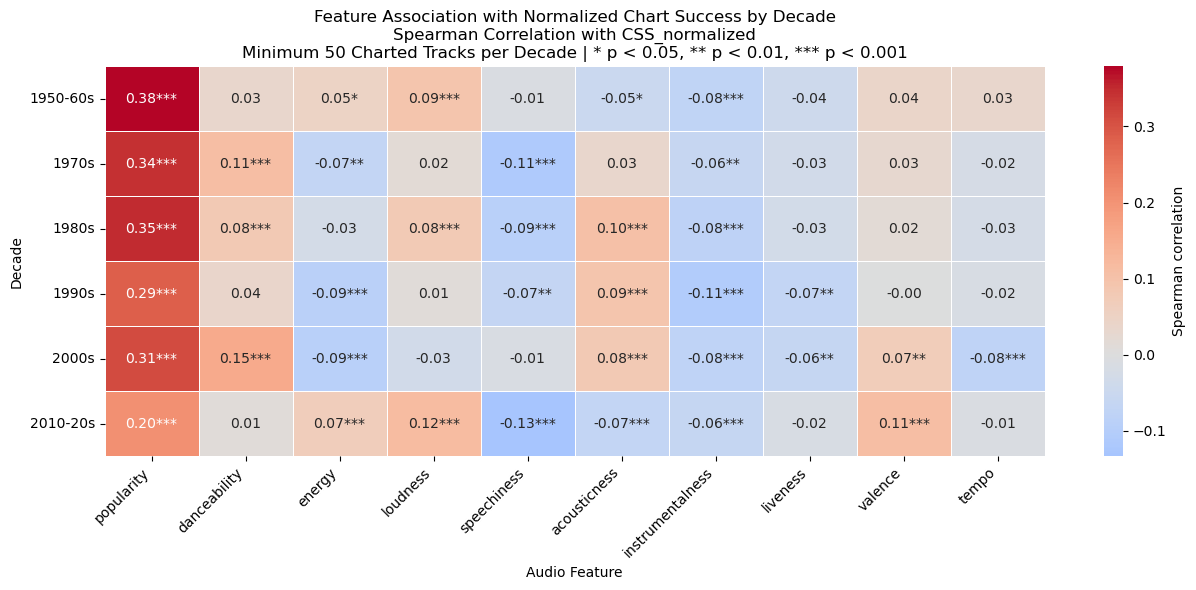

In [7]:


from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()




selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]




min_tracks = 50

valid_decades = (
    charted_df["decade_label"]
    .value_counts()
    .loc[lambda x: x >= min_tracks]
    .index
)

charted_decade_df = charted_df[
    charted_df["decade_label"].isin(valid_decades)
].copy()




decade_feature_css_corr = pd.DataFrame(
    index=sorted(valid_decades),
    columns=selected_features,
    dtype=float
)

decade_feature_css_pvalues = pd.DataFrame(
    index=sorted(valid_decades),
    columns=selected_features,
    dtype=float
)




for decade in sorted(valid_decades):
    
    decade_data = charted_decade_df[
        charted_decade_df["decade_label"] == decade
    ]

    for feature in selected_features:
        
        temp_df = decade_data[
            [feature, "CSS_normalized"]
        ].dropna()

        if len(temp_df) >= min_tracks:
            
            # Spearman requires variation in both variables
            if temp_df[feature].nunique() < 2:
                continue

            if temp_df["CSS_normalized"].nunique() < 2:
                continue

            corr, p_value = spearmanr(
                temp_df[feature],
                temp_df["CSS_normalized"]
            )

            decade_feature_css_corr.loc[decade, feature] = corr
            decade_feature_css_pvalues.loc[decade, feature] = p_value




decade_feature_css_corr = decade_feature_css_corr.round(3)
decade_feature_css_pvalues = decade_feature_css_pvalues.round(5)




annot_matrix = decade_feature_css_corr.copy().astype(str)

for decade in decade_feature_css_corr.index:
    
    for feature in decade_feature_css_corr.columns:
        
        corr_value = decade_feature_css_corr.loc[decade, feature]
        p_value = decade_feature_css_pvalues.loc[decade, feature]

        if pd.isna(corr_value):
            annot_matrix.loc[decade, feature] = ""

        elif p_value < 0.001:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}***"

        elif p_value < 0.01:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}**"

        elif p_value < 0.05:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}*"

        else:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}"




plt.figure(figsize=(13, 6))

sns.heatmap(
    decade_feature_css_corr,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Spearman correlation"}
)

plt.title(
    "Feature Association with Normalized Chart Success by Decade\n"
    "Spearman Correlation with CSS_normalized\n"
    f"Minimum {min_tracks} Charted Tracks per Decade | "
    "* p < 0.05, ** p < 0.01, *** p < 0.001"
)

plt.xlabel("Audio Feature")
plt.ylabel("Decade")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
5.6 Audio features as indicators of charted status by genre

In [ ]:
This heatmap examines whether each Spotify audio feature is associated with a track being charted rather than non-charted within each music genre.

The analysis again as in point 5.4 uses charted_binary, where:

1 = Charted
0 = Non-Charted

Because the dependent variable is binary, the graph uses point-biserial correlation. This measures whether higher values of a numerical feature are associated with a greater likelihood that a track belongs to the charted group.

Positive values mean that higher feature values are more common among charted tracks within that genre. Negative values mean that higher feature values are more common among non-charted tracks. Values close to zero suggest that the feature does not strongly separate charted and non-charted songs for that genre.

The stars show statistical significance:

*   p < 0.05
**  p < 0.01
*** p < 0.001

In simple words, this graph helps answer the question:

Within each genre, which audio features make a track more likely to be charted?

For example, if danceability has a positive and statistically significant value for pop, this suggests that more danceable pop songs are more likely to appear on Billboard than less danceable pop songs. If instrumentalness has a negative value for rock, this suggests that more instrumental rock tracks are less likely to be charted.

This graph is useful because genre strongly affects the meaning of audio features. A high energy value may be normal in rock or metal, but more distinctive in acoustic or soul music. Therefore, analyzing all songs together may hide genre-specific relationships. By calculating the correlation separately within each genre, the heatmap shows whether the same feature behaves differently across musical styles.

A limitation of this graph is that correlation does not prove causation. A positive value does not mean that increasing danceability causes a song to chart. It only means that, within the available data, charted tracks in that genre tend to have higher values for that feature.

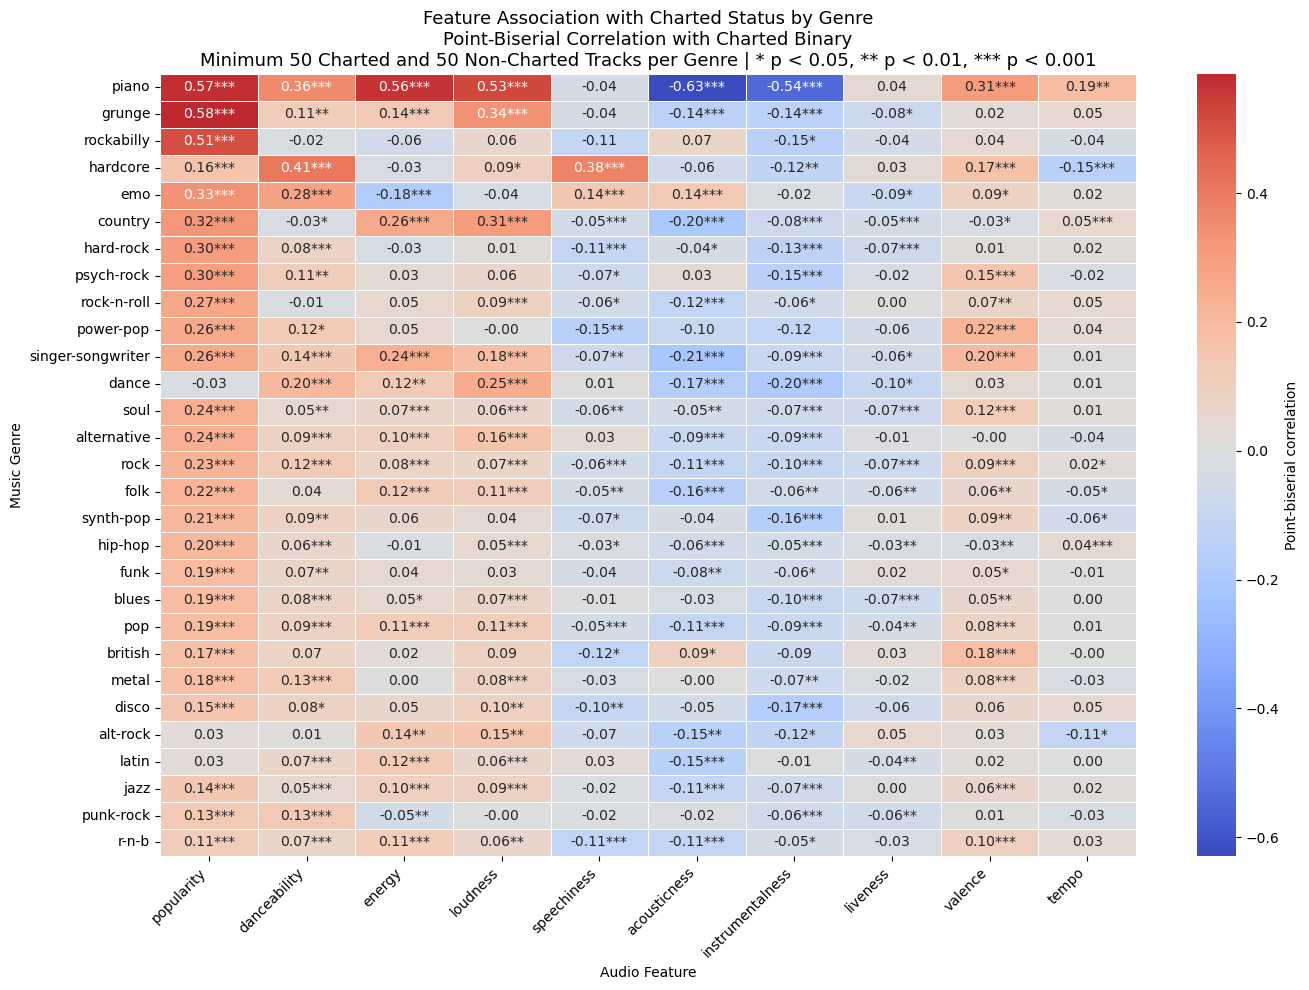

In [6]:

from scipy.stats import pointbiserialr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


audio_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_charted = 50
min_non_charted = 50



analysis_df = final_df[
    ["track_genre", "charted_binary"] + audio_features
].dropna(
    subset=["track_genre", "charted_binary"]
).copy()


corr_results = {}
pvalue_results = {}

for genre, group in analysis_df.groupby("track_genre"):

    class_counts = group["charted_binary"].value_counts()

    charted_count = class_counts.get(1, 0)
    non_charted_count = class_counts.get(0, 0)

    # Require at least 50 charted and 50 non-charted tracks
    if charted_count < min_charted:
        continue

    if non_charted_count < min_non_charted:
        continue

    feature_corrs = {}
    feature_pvalues = {}

    for feature in audio_features:

        temp = group[[feature, "charted_binary"]].dropna()

        class_counts_temp = temp["charted_binary"].value_counts()

        charted_count_temp = class_counts_temp.get(1, 0)
        non_charted_count_temp = class_counts_temp.get(0, 0)

       
        if charted_count_temp < min_charted:
            feature_corrs[feature] = np.nan
            feature_pvalues[feature] = np.nan
            continue

        if non_charted_count_temp < min_non_charted:
            feature_corrs[feature] = np.nan
            feature_pvalues[feature] = np.nan
            continue

        # Feature must have variation
        if temp[feature].nunique() < 2:
            feature_corrs[feature] = np.nan
            feature_pvalues[feature] = np.nan
            continue

        corr, p_value = pointbiserialr(
            temp["charted_binary"],
            temp[feature]
        )

        feature_corrs[feature] = corr
        feature_pvalues[feature] = p_value

    corr_results[genre] = feature_corrs
    pvalue_results[genre] = feature_pvalues


genre_feature_chart_corr = (
    pd.DataFrame(corr_results)
    .T
    .round(3)
)

genre_feature_chart_pvalues = (
    pd.DataFrame(pvalue_results)
    .T
)



genre_feature_chart_corr = genre_feature_chart_corr.dropna(how="all")

genre_feature_chart_pvalues = genre_feature_chart_pvalues.reindex(
    index=genre_feature_chart_corr.index,
    columns=genre_feature_chart_corr.columns
)



genre_feature_chart_corr = genre_feature_chart_corr.loc[
    genre_feature_chart_corr
    .abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .index
]

genre_feature_chart_pvalues = genre_feature_chart_pvalues.reindex(
    index=genre_feature_chart_corr.index,
    columns=genre_feature_chart_corr.columns
)



annot_matrix = genre_feature_chart_corr.copy().astype(str)

for genre in genre_feature_chart_corr.index:
    for feature in genre_feature_chart_corr.columns:

        corr_value = genre_feature_chart_corr.loc[genre, feature]
        p_value = genre_feature_chart_pvalues.loc[genre, feature]

        if pd.isna(corr_value):
            annot_matrix.loc[genre, feature] = ""

        elif p_value < 0.001:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}***"

        elif p_value < 0.01:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}**"

        elif p_value < 0.05:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}*"

        else:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}"



plt.figure(figsize=(14, 10))

sns.heatmap(
    genre_feature_chart_corr,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Point-biserial correlation"}
)

plt.title(
    "Feature Association with Charted Status by Genre\n"
    "Point-Biserial Correlation with Charted Binary\n"
    f"Minimum {min_charted} Charted and {min_non_charted} Non-Charted Tracks per Genre | "
    "* p < 0.05, ** p < 0.01, *** p < 0.001",
    fontsize=13
)

plt.xlabel("Audio Feature")
plt.ylabel("Music Genre")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
5.7 Audio features and normalized Billboard success by genre

In [ ]:
This heatmap focuses only on tracks that already appeared on the Billboard chart. Instead of comparing charted and non-charted tracks, it investigates whether certain audio features are associated with stronger chart performance among charted songs.

The outcome variable is:

CSS_normalized

This variable represents the normalized Chart Success Score. Higher values indicate stronger Billboard performance, based on chart position and time spent on the chart.

The graph uses Spearman correlation between each Spotify audio feature and CSS_normalized within each genre. Spearman correlation is useful here because chart success values can be skewed. A few songs may become extremely successful, while most charted songs have more moderate success. Spearman correlation is less sensitive to extreme values than Pearson correlation because it focuses on rank-based relationships.

Positive values mean that higher values of the feature are associated with higher normalized chart success within that genre. Negative values mean that higher values of the feature are associated with lower normalized chart success. Values close to zero suggest a weak relationship.

The stars show statistical significance:

*   p < 0.05
**  p < 0.01
*** p < 0.001

In simple words, this graph helps answer the question:

Among songs that already charted, which features are related to becoming more successful within each genre?

For example, if energy has a positive and statistically significant value for dance, this suggests that more energetic dance tracks tend to achieve higher normalized chart success. If acousticness has a negative value for pop, this suggests that more acoustic pop songs may have lower chart success compared with less acoustic pop songs.

This heatmap is different from the charted-status heatmap. The charted-status heatmap asks whether a song is likely to chart at all. This heatmap asks whether a song that has already charted performs better or worse. Therefore, it gives a more detailed view of chart performance, not just chart entry.

This analysis is useful because the factors that help a song enter the chart may not be the same factors that help it stay successful for many weeks. For example, a feature might be associated with chart entry but have little relationship with long-term chart strength.

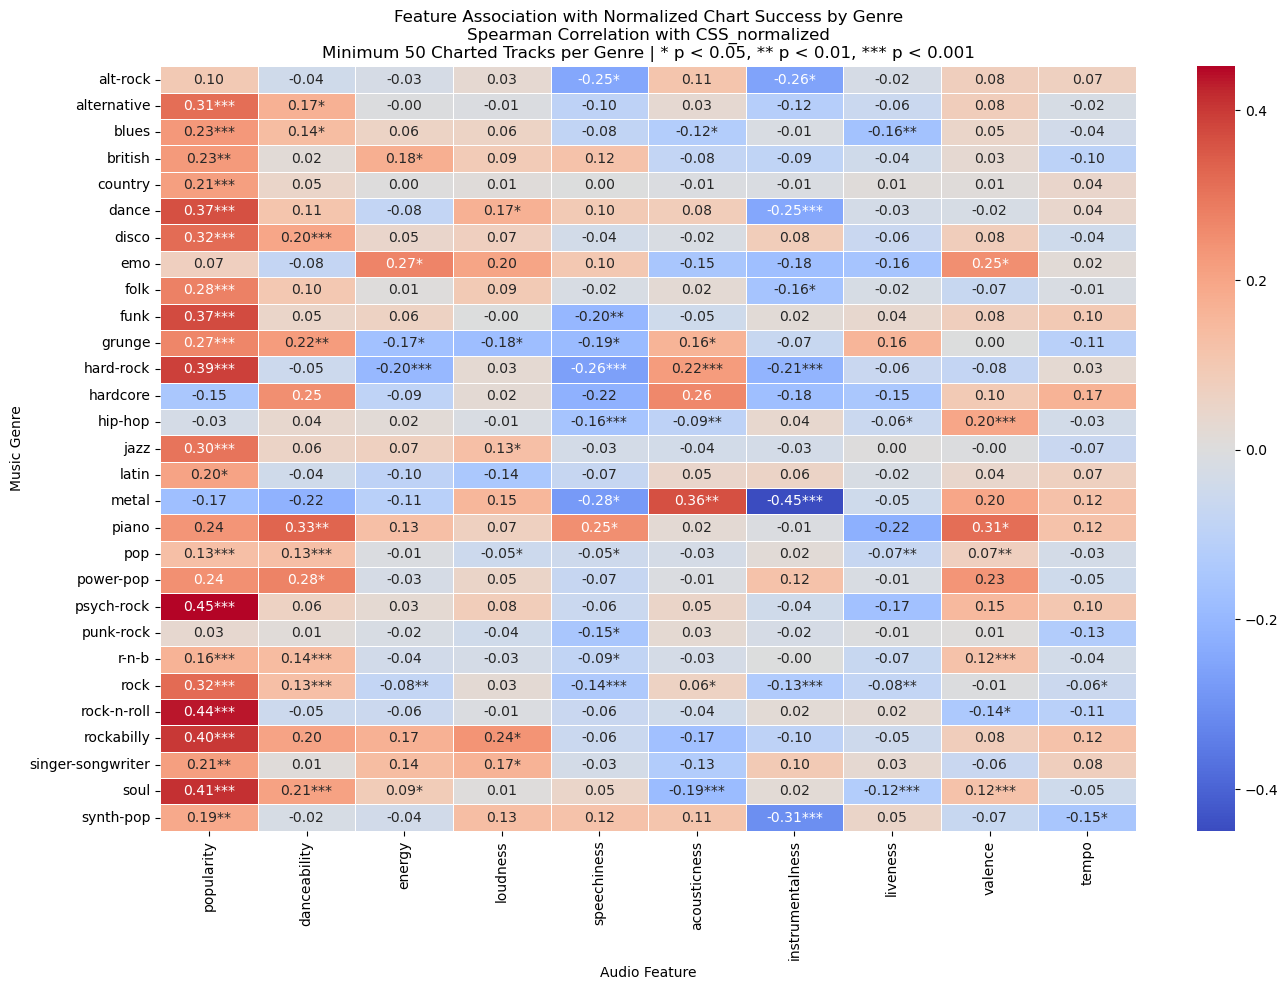

In [4]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

audio_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_tracks = 50

charted_df = final_df.loc[
    final_df["charted_label"].eq("Charted"),
    ["track_genre", "CSS_normalized"] + audio_features
].dropna(subset=["track_genre", "CSS_normalized"])

genre_counts = charted_df["track_genre"].value_counts()
valid_genres = genre_counts[genre_counts >= min_tracks].index

charted_df = charted_df[
    charted_df["track_genre"].isin(valid_genres)
]

corr_results = {}
pvalue_results = {}

for genre, group in charted_df.groupby("track_genre"):
    feature_corrs = {}
    feature_pvalues = {}

    for feature in audio_features:
        temp = group[[feature, "CSS_normalized"]].dropna()

        if (
            len(temp) >= min_tracks
            and temp[feature].nunique() > 1
            and temp["CSS_normalized"].nunique() > 1
        ):
            corr, p_value = spearmanr(
                temp[feature],
                temp["CSS_normalized"]
            )

            feature_corrs[feature] = corr
            feature_pvalues[feature] = p_value

        else:
            feature_corrs[feature] = np.nan
            feature_pvalues[feature] = np.nan

    corr_results[genre] = feature_corrs
    pvalue_results[genre] = feature_pvalues


genre_feature_css_corr = (
    pd.DataFrame(corr_results)
    .T
    .round(3)
)

genre_feature_css_pvalues = (
    pd.DataFrame(pvalue_results)
    .T
)


# Create annotation matrix with stars
annot_matrix = genre_feature_css_corr.copy().astype(str)

for genre in genre_feature_css_corr.index:
    for feature in genre_feature_css_corr.columns:

        corr_value = genre_feature_css_corr.loc[genre, feature]
        p_value = genre_feature_css_pvalues.loc[genre, feature]

        if pd.isna(corr_value):
            annot_matrix.loc[genre, feature] = ""

        elif p_value < 0.001:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}***"

        elif p_value < 0.01:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}**"

        elif p_value < 0.05:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}*"

        else:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}"


# Show only the heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    genre_feature_css_corr,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Feature Association with Normalized Chart Success by Genre\n"
    "Spearman Correlation with CSS_normalized\n"
    f"Minimum {min_tracks} Charted Tracks per Genre | "
    "* p < 0.05, ** p < 0.01, *** p < 0.001"
)

plt.xlabel("Audio Feature")
plt.ylabel("Music Genre")

plt.tight_layout()
plt.show()

6. Hypotheses and methodology


In [ ]:
7. Results

In [ ]:
8. Discussion

In [ ]:
9. Conclusion

6. Methodology

The project follows a multi-stage analytical workflow involving data cleaning, exploratory analysis, visualization, and statistical testing.

The first stage involves data cleaning and preparation. Duplicate records are removed, missing values are handled, and song titles and artist names are normalized to improve matching accuracy between datasets. Datatypes are validated to ensure consistency during statistical analysis. After preprocessing, the merged dataset is inspected through descriptive statistics and exploratory visualization in order to verify data quality.

The second stage consists of exploratory data analysis. Histograms are used to inspect variable distributions, while boxplots allow comparison of feature ranges across genres. Scatterplots are used to visualize relationships between audio features and chart performance, and correlation heatmaps provide an overview of relationships among numerical variables.

The third stage focuses on statistical analysis. Pearson correlation coefficients are calculated in order to measure relationships between audio features such as danceability, energy, loudness, and valence, and Billboard chart indicators including peak position and weeks on chart.

The Pearson correlation coefficient is defined as:

r=
∑
i=1
n
	​

(x
i
	​

−
x
ˉ
)
2
∑
i=1
n
	​

(y
i
	​

−
y
ˉ
	​

)
2
	​

∑
i=1
n
	​

(x
i
	​

−
x
ˉ
)(y
i
	​

−
y
ˉ
	​

)
	​




Confidence intervals are computed for selected variables in order to estimate population parameters. A 95% confidence interval is calculated using:

x
ˉ
±z
n
	​

σ
	​




ANOVA tests are then used to compare audio-feature means across genres. The null hypothesis for ANOVA assumes equality between all group means:

H
0
	​

:μ
1
	​

=μ
2
	​

=⋯=μ
n
	​




Additionally, two-sample t-tests are used to compare highly ranked songs against lower-ranked songs. Statistical significance is evaluated using a significance threshold of:

α=0.05



The statistical analysis is performed using Python libraries including pandas, NumPy, SciPy, and matplotlib.

References

Billboard. (2025). Billboard Hot 100 charts. Retrieved from https://www.billboard.com/charts/hot-100/

Datta, H., Knox, G., & Bronnenberg, B. (2018). Changing their tune: How consumers’ adoption of online streaming affects music consumption and discovery. Marketing Science, 37(1), 5–21.

Dhanaraj, R., & Logan, B. (2005). Automatic prediction of hit songs. Proceedings of the International Conference on Music Information Retrieval, 488–491.

Herremans, D., Martens, D., & Sörensen, K. (2014). Dance hit song prediction. Journal of New Music Research, 43(3), 291–302.

Morris, J. W., & Powers, D. (2015). Control, curation and musical experience in streaming music services. Creative Industries Journal, 8(2), 106–122.

Pachet, F., & Roy, P. (2008). Hit song science is not yet a science. Proceedings of the International Society for Music Information Retrieval Conference, 355–360.

Schedl, M., Gómez, E., & Urbano, J. (2014). Music information retrieval: Recent developments and applications. Foundations and Trends in Information Retrieval, 8(2–3), 127–261.

Serrà, J., Corral, Á., Boguñá, M., Haro, M., & Arcos, J. L. (2012). Measuring the evolution of contemporary western popular music. Scientific Reports, 2(521), 1–6.

Spotify for Developers. (2025). Audio features object. Retrieved from https://developer.spotify.com/documentation/web-api/reference/get-audio-features

Appendix:

Spotify Dataset
https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset?resource=download



In [ ]:
##Appendix A Data preparation: Loading, Cleaning and Merging the 4 datasets

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import zscore
import re


from sklearn.preprocessing import StandardScaler


### Loading initial csv data, defining and renaming columns


spotify_df = pd.read_csv("initial_data/spotify_tracks.csv")
billboard_df = pd.read_csv("initial_data/billboard_hot_100.csv")
spotify_year_df = pd.read_csv("initial_data/spotify_160k_dataset.csv")


spotify_df = spotify_df[[
    'track_name',
    'artists',
    'track_genre',
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]]

billboard_df = billboard_df[[
    'song',
    'artist',
    'date',
    'rank',
    'peak-rank',
    'weeks-on-board'
]]

spotify_year_df = spotify_year_df[[
    'name',
    'artists',
    'year',
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]]

spotify_year_df = spotify_year_df.rename(columns={
    'name': 'track_name'
})

billboard_df = billboard_df.rename(columns={
    'song': 'track_name',
    'artist': 'artists',
    'peak-rank': 'peak_rank',
    'weeks-on-board': 'weeks_on_board'
    
})



### Concatinating the two spotify datasets into one who combined file

spotify_combined_df = pd.concat(
    [spotify_df, spotify_year_df],
    ignore_index=True,
    sort=False
)


### Normalizing text for tracks and artist, removing terms that could hurt merging


def clean_text(text):

    if pd.isna(text):
        return text

    text = text.lower()

    remove_terms = [
        'remastered',
        'remixed',
        'live',
        'deluxe',
        'mono',
        'stereo'
    ]

    for term in remove_terms:
        text = text.replace(term, '')

    text = re.sub(r"[^a-z0-9\\s]", "", text)

    text = re.sub(r"\\s+", " ", text)

    return text.strip()


spotify_combined_df['track_name'] = (
    spotify_combined_df['track_name']
    .apply(clean_text)
)

spotify_combined_df['artists'] = (
    spotify_combined_df['artists']
    .apply(clean_text)
)

billboard_df['track_name'] = (
    billboard_df['track_name']
    .apply(clean_text)
)

billboard_df['artists'] = (
    billboard_df['artists']
    .apply(clean_text)
)



### Removing null values and duplicates and exporing into a view csv



billboard_df = billboard_df.dropna()

spotify_combined_df = spotify_combined_df.drop_duplicates(
    subset=['track_name', 'artists']
)

spotify_combined_df['track_name'] = (
    spotify_combined_df['track_name']
    .replace('', np.nan)
)

spotify_combined_df['artists'] = (
    spotify_combined_df['artists']
    .replace('', np.nan)
)

spotify_combined_df = spotify_combined_df.dropna(
    subset=['track_name', 'artists']
)
billboard_df = billboard_df.drop_duplicates()



spotify_combined_df.to_csv(
    "intermediary_data/spotify_combined_df.csv",
    index=False
)




### First creating a weekly-score (CSS) rank for each week record for a track.
### Then creating a summarized table from Billboard to extract the sum of weekly-scores, max weeks in the billboard and peak rank.


billboard_df['weekly_score'] = (
    (101 - billboard_df['rank']) / 100
)

billboard_df['date'] = pd.to_datetime(
    billboard_df['date']
)
billboard_df['chart_year'] = (
    billboard_df['date'].dt.year
)

css_summary_df = billboard_df.groupby(
    ['track_name', 'artists'],
    as_index=False
).agg({
    'weekly_score': 'sum',
    'weeks_on_board': 'max',
    'peak_rank': 'min',
    'chart_year': 'min'
})

css_summary_df = css_summary_df.rename(columns={
    'weekly_score': 'CSS'
})

css_summary_df['CSS'] = (
    css_summary_df['CSS']
    .round(2)
)

css_summary_df['CSS_normalized'] = (
    zscore(css_summary_df['CSS']) * 100
).round(2)


### Merging the summarized billboard table with the combined spotify table and cleaning any duplicates and null values for any case.

merged_df_billboard_spotify = pd.merge(
    spotify_combined_df,
    css_summary_df,
    on=['track_name', 'artists'],
    how='inner'
)

merged_df_billboard_spotify = (
    merged_df_billboard_spotify.drop(
        columns=['year']
    )
)

merged_df_billboard_spotify.drop_duplicates(
    subset=['track_name', 'artists']

)
merged_df_billboard_spotify.to_csv(
    "intermediary_data/merged_df_billboard_spotify.csv",
    index=False
)



### Now there will be a cleaned copy which is done now, because it was intented ot have as much data as possible for the inner merge with billboard summartized table above.
### Creating a filtered copy of the spotify combined table with years range that responds to the billboard years active range
### Removing any records without year.




spotify_cleaned_combined_df = spotify_combined_df.copy()

spotify_cleaned_combined_df = spotify_cleaned_combined_df[
    (
        spotify_cleaned_combined_df['year'] >= 1958
    )
    &
    (
        spotify_cleaned_combined_df['year'] <= 2021
    )
]



spotify_cleaned_combined_df = spotify_cleaned_combined_df.dropna(
    subset=['year']
)

spotify_cleaned_combined_df['year'] = (
    spotify_cleaned_combined_df['year']
    .astype(int)
)

spotify_cleaned_combined_df = (
    spotify_cleaned_combined_df.reset_index(
        drop=True
    )
)


spotify_cleaned_combined_df = spotify_cleaned_combined_df.rename(columns={
    'year': 'chart_year'
})

spotify_cleaned_combined_df.to_csv(
    "intermediary_data/spotify_cleaned_combined.csv",
    index=False
)



### Creating a concatinated table which will have both charted and uncharted tracks. It is expected that there will be duplicates between charted and uncharted tracks.
###The table is sorted in such a way that removing duplicates will take from the records without Billboard characteristics.



billboard_spotify_combined_df = pd.concat(
    [
        spotify_cleaned_combined_df,
        merged_df_billboard_spotify
    ],
    ignore_index=True,
    sort=False
)

billboard_spotify_combined_df = billboard_spotify_combined_df.sort_values(
    by='CSS',
    ascending=False,
    na_position='last'
)

billboard_spotify_combined_df = billboard_spotify_combined_df.drop_duplicates(
    subset=['track_name', 'artists']
)



billboard_spotify_combined_df = billboard_spotify_combined_df.reset_index(
    drop=True
)




billboard_spotify_combined_df.to_csv(
    "final_data/billboard_spotify_combined_df.csv",
    index=False
)



### Importing reference table of genres filled in by AI tool (chatgpt) and merged in order to populate the data in track_genre column.




genre_df = pd.read_csv(
    "initial_data/genre_reference_table.csv",
    sep=",",
    encoding="cp1252",
    low_memory=False
)

billboard_spotify_combined_df = billboard_spotify_combined_df.drop(
    columns=['track_genre'],
    errors='ignore'
)

final_df = pd.merge(
    billboard_spotify_combined_df,
    genre_df,
    on=['track_name', 'artists'],
    how='left',
)


### Doing some reformat of data types, creating new columns such as binary whether the track is in a chart or not, 
### decade label based on year. And finally the columns are ordered.



final_df['weeks_on_board'] = pd.to_numeric(
    final_df['weeks_on_board'],
    errors='coerce'
).astype('Int64')




final_df = final_df.rename(columns={
    'chart_year': 'year'
})

final_df['year'] = pd.to_numeric(
    final_df['year'],
    errors='coerce'
)

final_df['decade'] = (
    (final_df['year'] // 10) * 10
).astype('Int64')

final_df['decade_label'] = (
    final_df['decade'].astype(str) + 's'
)

final_df['decade_label'] = (
    final_df['decade']
    .astype(str) + 's'
)

final_df['charted_binary'] = np.where(
    final_df['CSS'].notna(),
    1,
    0
)

final_df['charted_label'] = np.where(
    final_df['CSS'].notna(),
    "Charted",
    "Non-Charted"
)

final_df = final_df.replace(
    r'^\s*$',
    np.nan,
    regex=True
)

final_df["decade_label"] = final_df["decade_label"].replace({
    "1950s": "1950-60s",
    "1960s": "1950-60s",
    "2010s": "2010-20s",
    "2020s": "2010-20s"
})


final_df = final_df.dropna(subset=['artists'])
final_df = final_df.dropna(subset=['track_name'])
final_df = final_df.dropna(subset=['track_genre'])


billboard_spotify_combined_df = billboard_spotify_combined_df.drop_duplicates(
    subset=['track_name', 'artists']
)


final_df['weeks_on_board'] = pd.to_numeric(
    final_df['weeks_on_board'],
    errors='coerce'
).astype('Int64')

final_df['peak_rank'] = pd.to_numeric(
    final_df['peak_rank'],
    errors='coerce'
).astype('Int64')

desired_order = [
    'track_name',
    'artists',
    'track_genre',
    'year',
    'decade',
    'decade_label',
]

remaining_columns = [
    col for col in final_df.columns
    if col not in desired_order + [
        'CSS',
        'CSS_normalized'
    ]
]

final_df = final_df[
    desired_order +
    remaining_columns +
    ['CSS', 'CSS_normalized']
]

final_df.to_csv(
    "final_data/final_df.csv",
    index=False
)



In [ ]:
##Appendix B Correlation analysys among the features

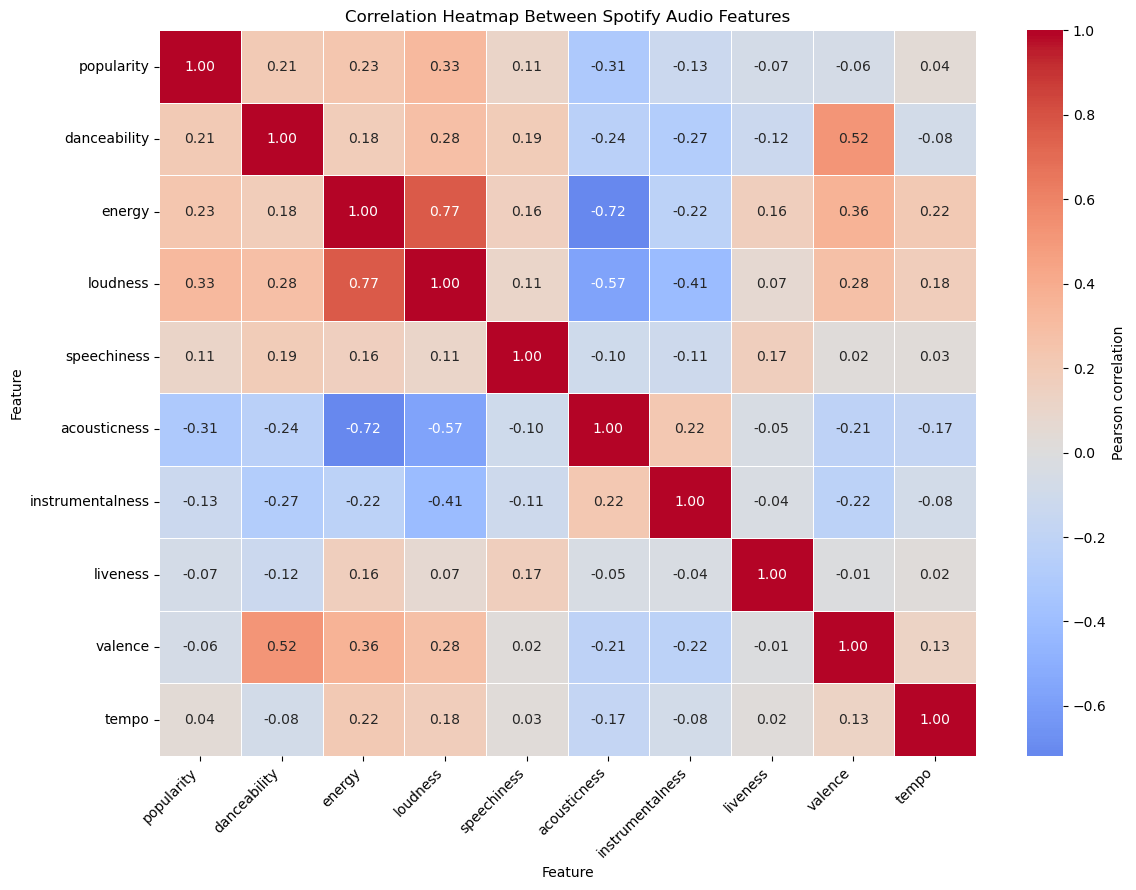

In [8]:
numeric_columns = final_df.select_dtypes(include=["number"]).columns

corr_df = final_df[numeric_columns].copy()


# -------------------------
# 2. Optional: remove identifier/time/outcome columns
# -------------------------
# Use this version if you want only Spotify/audio-related numeric features.
# If you want absolutely all numeric columns, skip this block.

excluded_columns = [
    "year",
    "decade",
    "weeks_on_board",
    "peak_rank",
    "charted_binary",
    "CSS",
    "CSS_normalized"
]

feature_columns = [
    col for col in numeric_columns
    if col not in excluded_columns
]

corr_df = final_df[feature_columns].copy()


# -------------------------
# 3. Calculate correlation matrix
# -------------------------

feature_corr_matrix = corr_df.corr(method="pearson")


# -------------------------
# 4. Plot heatmap
# -------------------------

plt.figure(figsize=(12, 9))

sns.heatmap(
    feature_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Correlation Heatmap Between Spotify Audio Features")
plt.xlabel("Feature")
plt.ylabel("Feature")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
##Appendix C - numerical representation of trend analysis of features throughout the decades

In [217]:




excluded_columns = [
    "year",
    "decade",
    "weeks_on_board",
    "peak_rank",
    "charted_binary",
    "CSS",
    "CSS_normalized"
]

numeric_columns = final_df.select_dtypes(include=["number"]).columns

feature_columns = [
    col for col in numeric_columns
    if col not in excluded_columns
]

standardized_df = final_df.copy()

for col in feature_columns:
    standardized_df[col + "_z"] = (
        standardized_df[col] - standardized_df[col].mean()
    ) / standardized_df[col].std()

z_columns = [col + "_z" for col in feature_columns]

decade_feature_means_z = (
    standardized_df
    .groupby("decade_label", observed=True)[z_columns]
    .mean()
    .sort_index()
    .round(3)
)

decade_feature_means_z.columns = feature_columns

decade_feature_means_z

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
decade_label,,,,,,,,,,
1950-60s,-1.038,-0.322,-0.640,-0.528,-0.178,0.843,0.191,0.033,0.028,-0.147
1970s,-0.376,-0.152,-0.103,-0.249,-0.173,0.077,0.025,0.087,0.176,0.016
1980s,-0.242,-0.024,0.160,-0.192,-0.147,-0.245,0.048,0.002,0.100,0.070
1990s,0.172,0.112,0.124,0.057,0.080,-0.234,-0.024,-0.015,0.024,-0.004
2000s,0.546,0.146,0.373,0.543,0.143,-0.329,-0.126,-0.038,-0.041,0.057
2010-20s,1.207,0.324,0.260,0.528,0.327,-0.331,-0.165,-0.080,-0.294,0.045


In [ ]:
## Appendix D - Top 3 best performing CSS genres for each decade (minimum 100 sample)

In [230]:


min_tracks = 100

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

top3_genres_by_decade_css = (
    charted_df
    .dropna(subset=["decade_label", "track_genre", "CSS_normalized"])
    .groupby(["decade_label", "track_genre"], as_index=False, observed=True)
    .agg(
        mean_CSS_normalized=("CSS_normalized", "mean"),
        number_of_tracks=("track_genre", "count")
    )
)

# Keep only genres with at least 10 charted tracks in that decade
top3_genres_by_decade_css = top3_genres_by_decade_css[
    top3_genres_by_decade_css["number_of_tracks"] >= min_tracks
]

# Sort and select Top 3 per decade
top3_genres_by_decade_css = (
    top3_genres_by_decade_css
    .sort_values(
        ["decade_label", "mean_CSS_normalized"],
        ascending=[True, False]
    )
    .groupby("decade_label", observed=True)
    .head(3)
    .reset_index(drop=True)
)

# Add rank within each decade
top3_genres_by_decade_css["rank_within_decade"] = (
    top3_genres_by_decade_css
    .groupby("decade_label", observed=True)["mean_CSS_normalized"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Round score
top3_genres_by_decade_css["mean_CSS_normalized"] = (
    top3_genres_by_decade_css["mean_CSS_normalized"].round(3)
)

# Reorder columns
top3_genres_by_decade_css = top3_genres_by_decade_css[
    [
        "decade_label",
        "rank_within_decade",
        "track_genre",
        "mean_CSS_normalized",
        "number_of_tracks"
    ]
]

top3_genres_by_decade_css

,decade_label,rank_within_decade,track_genre,mean_CSS_normalized,number_of_tracks
0,1950-60s,1,rock-n-roll,34.210,187
1,1950-60s,2,pop,22.102,288
2,1950-60s,3,rock,10.076,102
3,1970s,1,pop,64.137,202
4,1970s,2,disco,57.721,163
5,1970s,3,soul,29.418,262
6,1980s,1,disco,88.974,105
7,1980s,2,pop,78.924,245
8,1980s,3,synth-pop,50.529,170
9,1990s,1,pop,115.926,180


In [ ]:
## Appendix E - Heatmap of how strong a given feature correlates to the standardized mean of CSS a certain genre in comparison to the others. The darker the colour the stronger the correlation, the lighter, vice versa.

In [9]:
selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_tracks = 50

genre_counts = final_df["track_genre"].value_counts()

valid_genres = genre_counts[
    genre_counts >= min_tracks
].index

genre_feature_df = final_df[
    final_df["track_genre"].isin(valid_genres)
].copy()

genre_feature_means = (
    genre_feature_df
    .groupby("track_genre")[selected_features]
    .mean()
)


genre_feature_means_z = genre_feature_means.apply(
    lambda col: (col - col.mean()) / col.std(),
    axis=0
).round(2)



NameError: name 'genre_feature_means_z' is not defined

<Figure size 1400x1000 with 0 Axes>

In [258]:
genre_feature_means_z.style \
    .background_gradient(cmap="Blues", subset=["danceability"]) \
    .background_gradient(cmap="Greens", subset=["energy"]) \
    .background_gradient(cmap="Purples", subset=["loudness"]) \
    .background_gradient(cmap="Oranges", subset=["speechiness"]) \
    .background_gradient(cmap="Reds", subset=["acousticness"]) \
    .background_gradient(cmap="Greys", subset=["instrumentalness"]) \
    .background_gradient(cmap="YlGn", subset=["liveness"]) \
    .background_gradient(cmap="PuRd", subset=["valence"]) \
    .background_gradient(cmap="YlOrBr", subset=["tempo"]) \
    .background_gradient(cmap="BuGn", subset=["popularity"]) \
    .format("{:.2f}")

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_genre,,,,,,,,,,
acoustic,1.37,0.36,0.05,0.87,-0.48,-0.36,-0.84,-0.47,-0.22,0.50
afrobeat,-1.31,1.15,0.95,0.55,0.12,-0.47,0.61,0.25,1.64,-1.08
alt-rock,1.44,-0.08,0.95,1.10,-0.39,-1.08,-0.58,-0.60,-0.37,1.12
alternative,0.17,-0.21,0.62,0.38,-0.21,-0.93,0.07,-0.21,-0.06,0.71
ambient,-0.09,-1.90,-1.75,-2.36,-0.54,1.11,3.06,-1.05,-2.27,-1.54
bluegrass,-0.97,0.09,-0.62,-0.48,-0.44,0.83,0.03,0.26,1.23,0.99
blues,-0.80,0.16,-0.17,-0.22,-0.33,0.11,-0.24,0.74,0.82,0.29
brazil,-0.42,-0.06,-1.06,-1.00,-0.38,1.14,-0.14,-0.38,0.53,-0.36
british,0.41,0.05,0.34,0.44,-0.39,-0.37,-0.35,-0.28,0.28,0.07


In [ ]:
## Appendix F - The heatmap shows how each decade correlates to the mean standardized CSS score for each genre

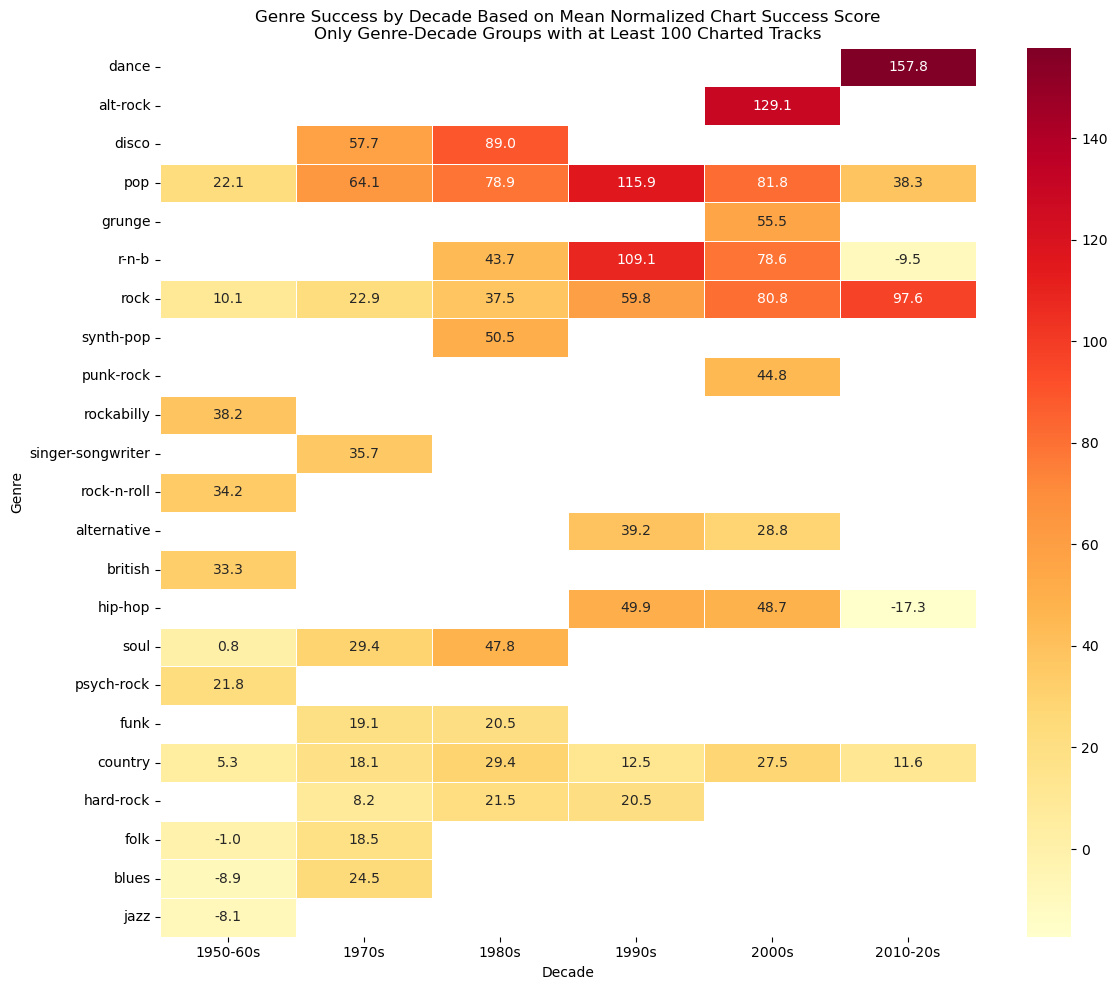

In [266]:
min_tracks = 50

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

decade_order = [
    "1950-60s",
    "1970s",
    "1980s",
    "1990s",
    "2000s",
    "2010-20s"
]

charted_df["decade_label"] = pd.Categorical(
    charted_df["decade_label"],
    categories=decade_order,
    ordered=True
)


genre_decade_css = (
    charted_df
    .dropna(subset=["decade_label", "track_genre", "CSS_normalized"])
    .groupby(["track_genre", "decade_label"], as_index=False, observed=True)
    .agg(
        mean_CSS_normalized=("CSS_normalized", "mean"),
        number_of_tracks=("track_genre", "count")
    )
)

genre_decade_css.head()

genre_decade_css_filtered = genre_decade_css[
    genre_decade_css["number_of_tracks"] >= min_tracks
].copy()

genre_decade_css_filtered["mean_CSS_normalized"] = (
    genre_decade_css_filtered["mean_CSS_normalized"].round(3)
)

genre_decade_css_filtered.sort_values(
    ["decade_label", "mean_CSS_normalized"],
    ascending=[True, False]
)

genre_decade_heatmap = genre_decade_css_filtered.pivot(
    index="track_genre",
    columns="decade_label",
    values="mean_CSS_normalized"
)

# Sort genres by their overall average CSS_normalized across decades
genre_decade_heatmap = genre_decade_heatmap.loc[
    genre_decade_heatmap.mean(axis=1).sort_values(ascending=False).index
]

genre_decade_heatmap

plt.figure(figsize=(12, 10))

sns.heatmap(
    genre_decade_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Genre Success by Decade Based on Mean Normalized Chart Success Score\n"
    "Only Genre-Decade Groups with at Least 50 Charted Tracks"
)
plt.xlabel("Decade")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [ ]:
## Appendix G - Heatmap of correlation to obtaining Chart Status for each feature separately, for each genre per decade (with sample of at least 20 chart and 30 non-chart tracks) 

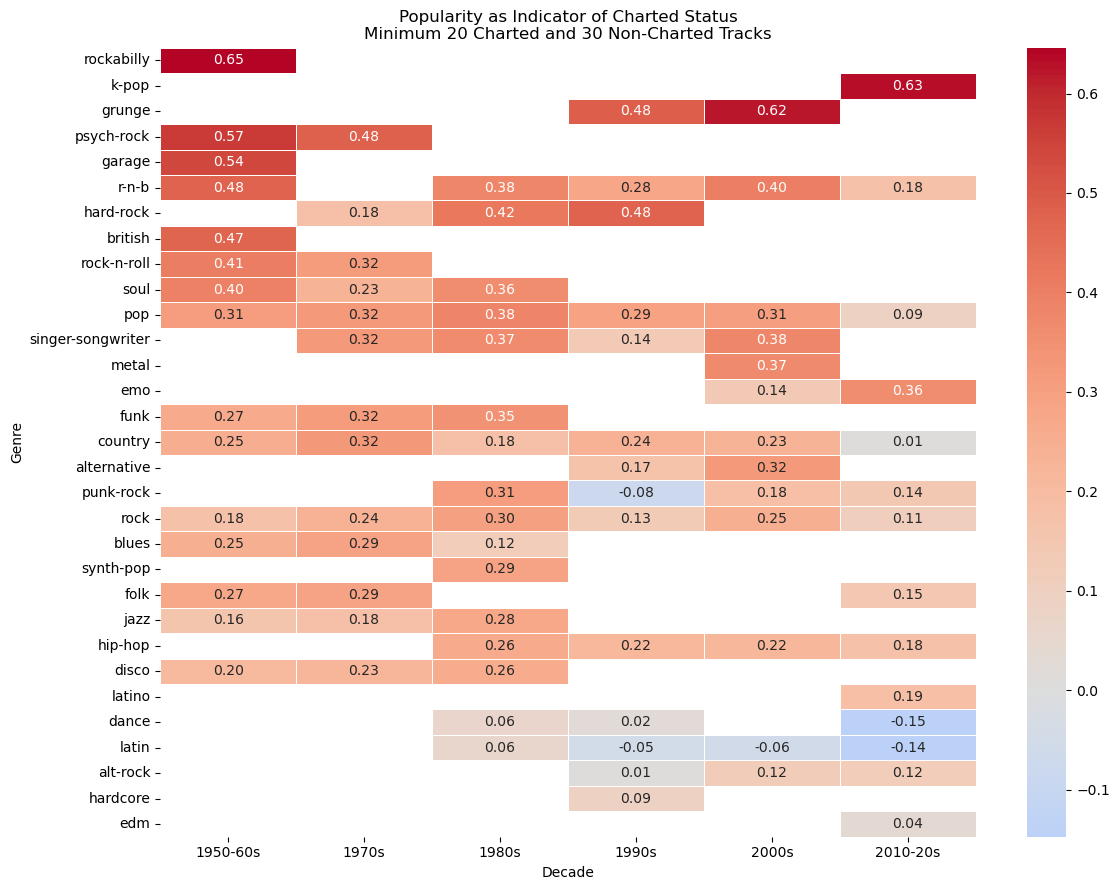

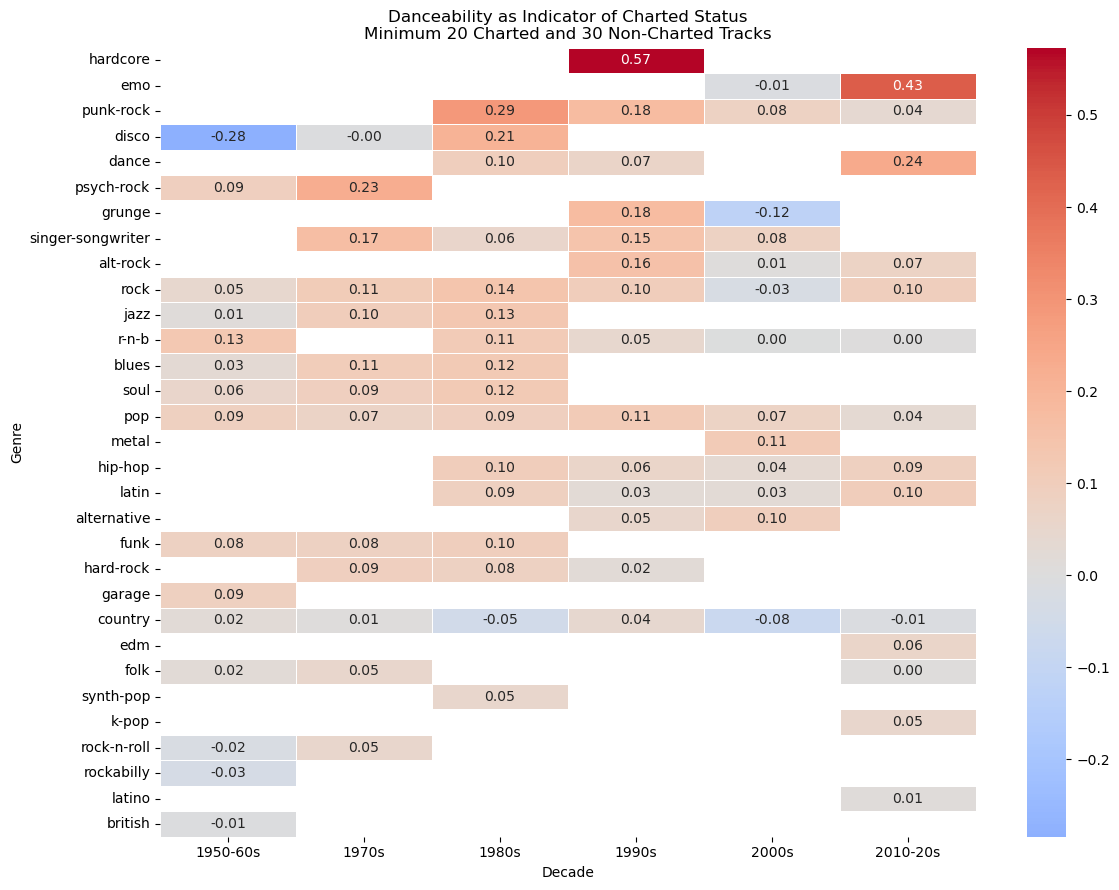

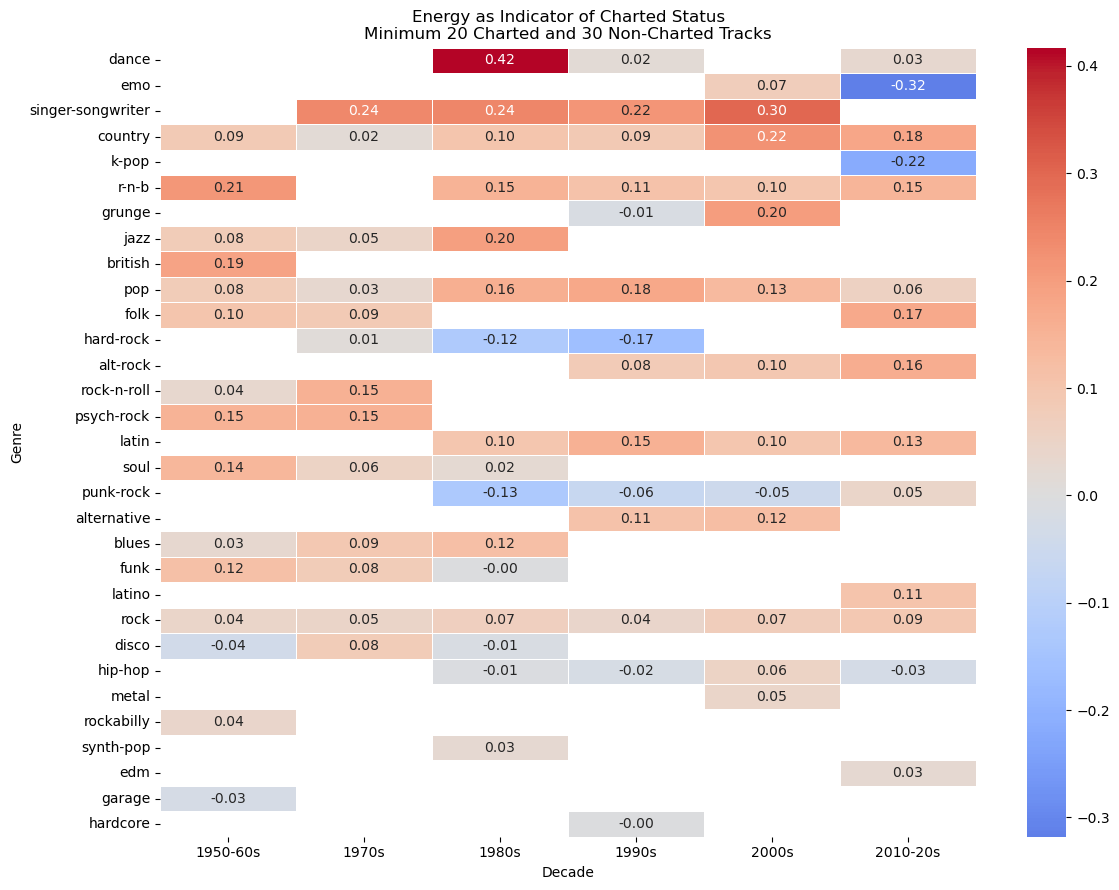

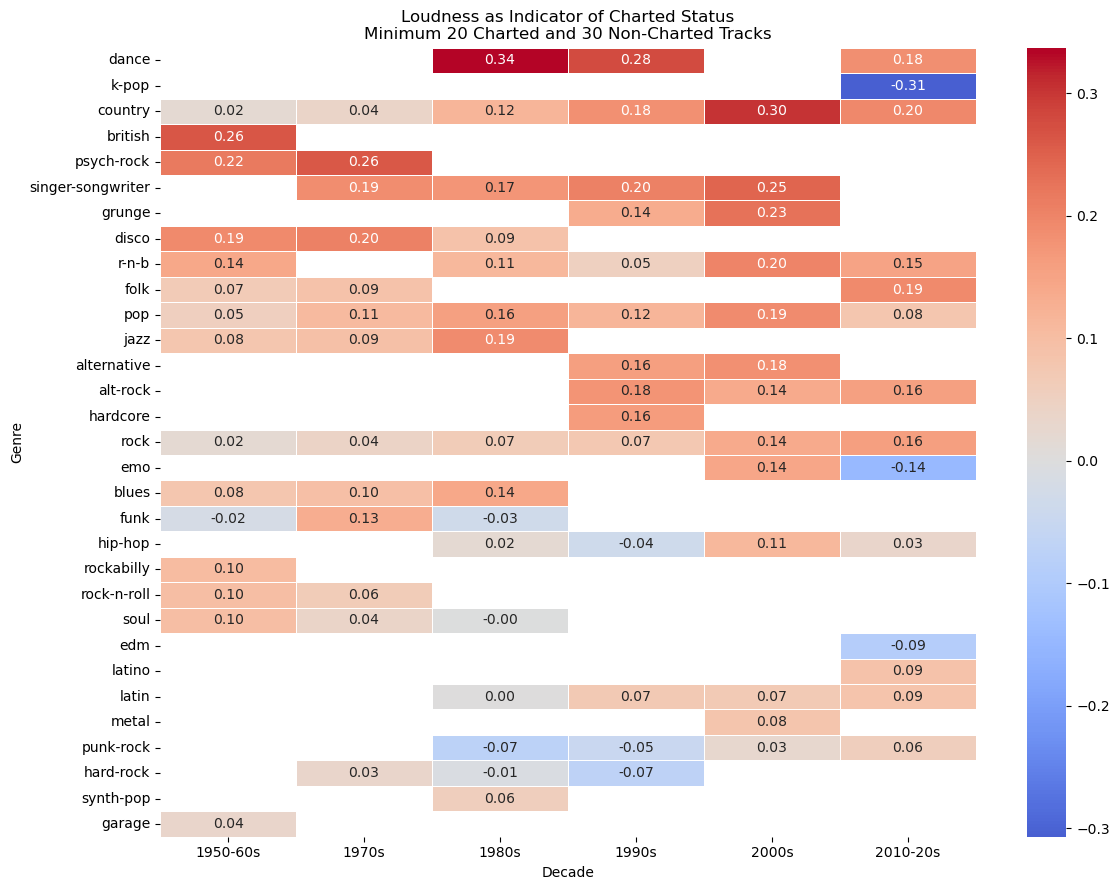

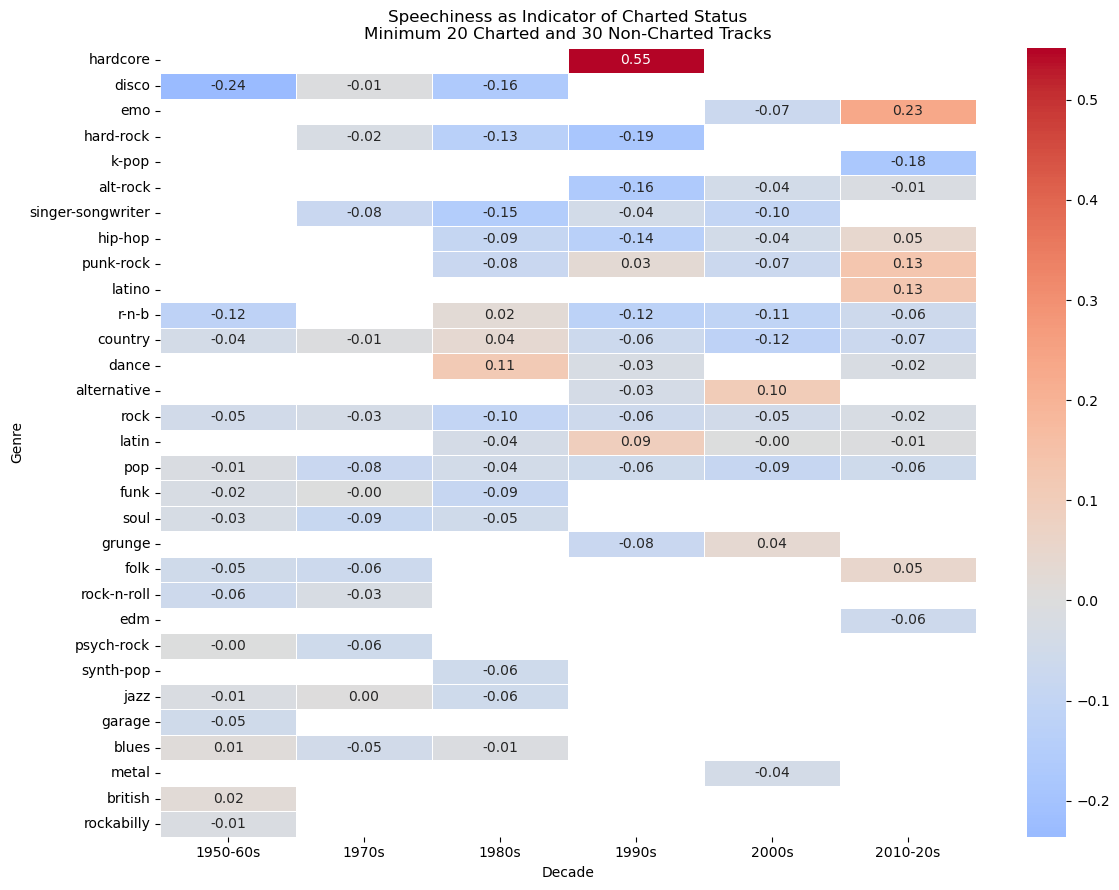

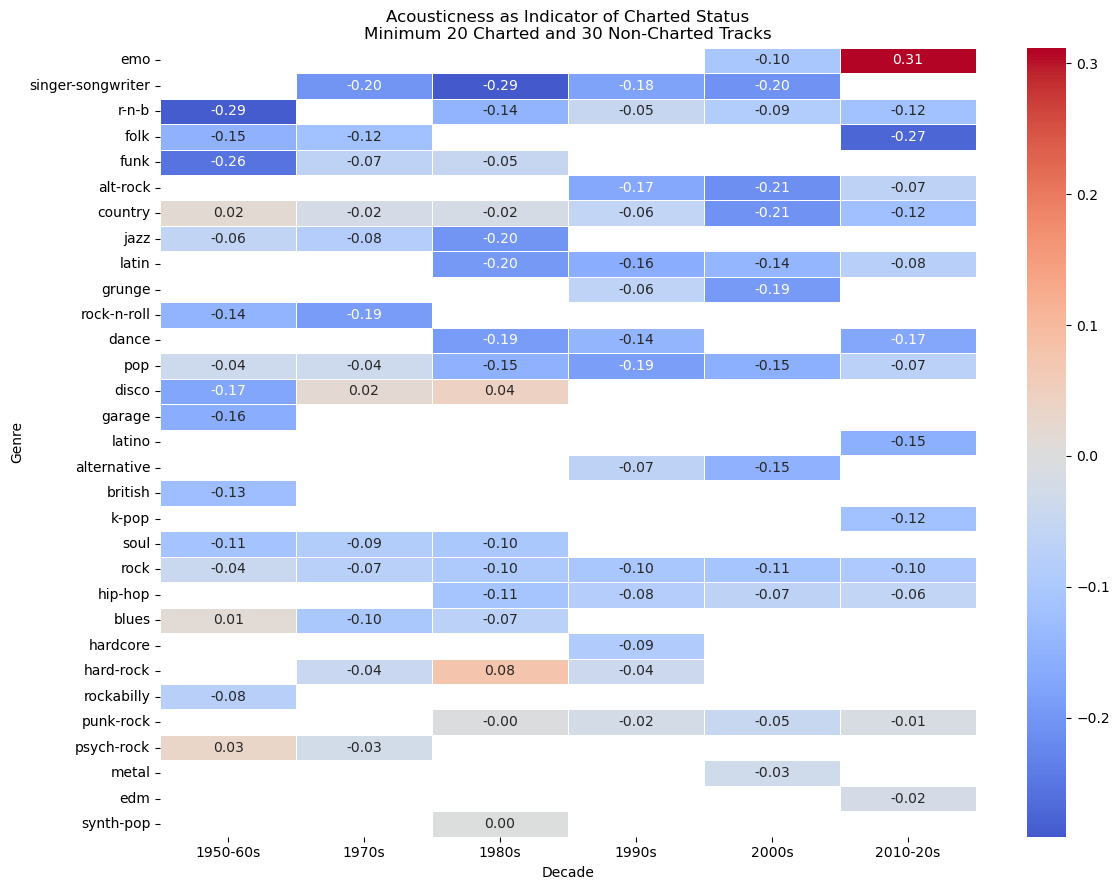

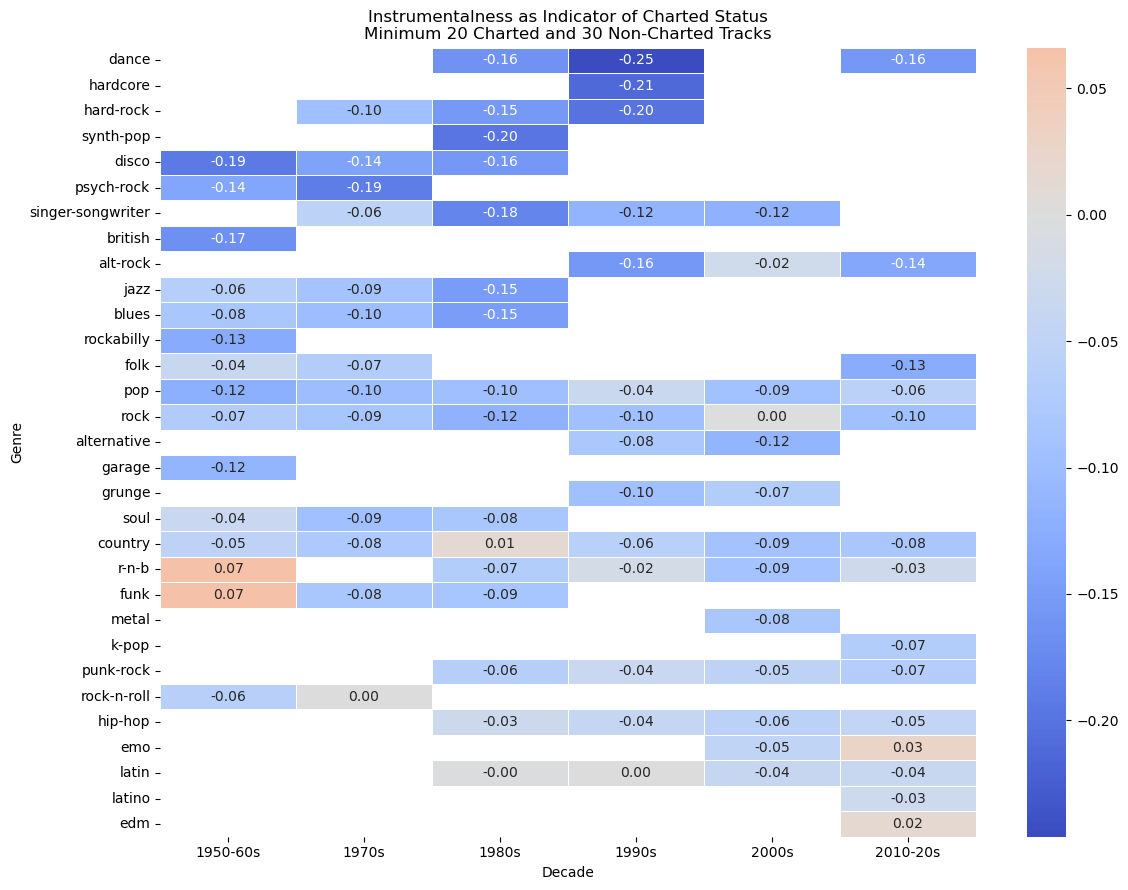

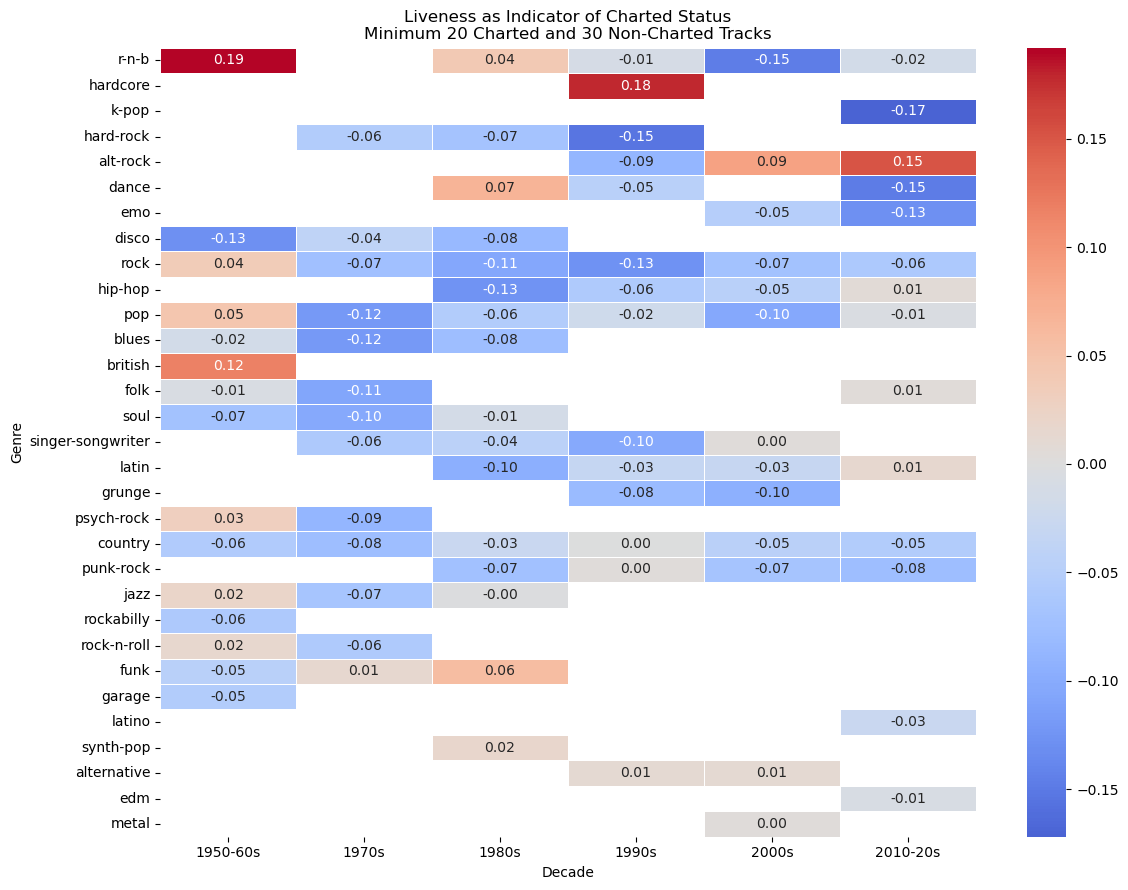

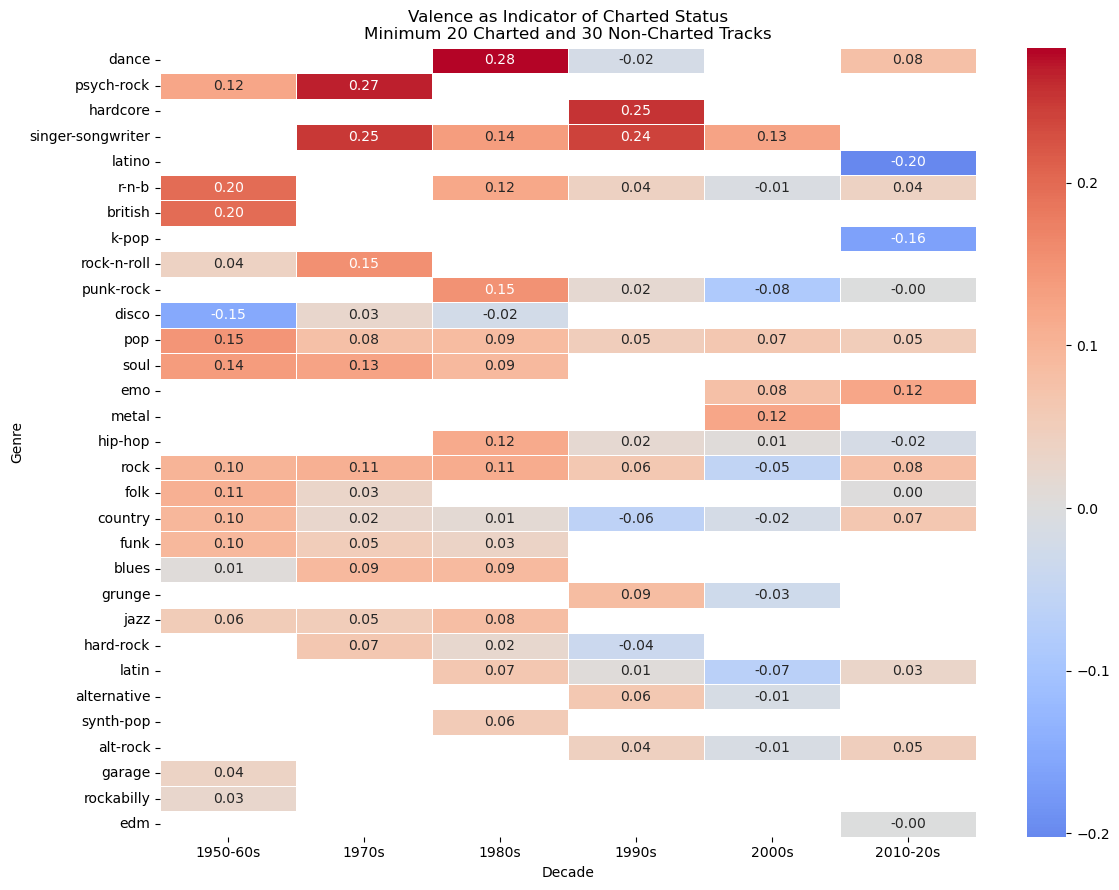

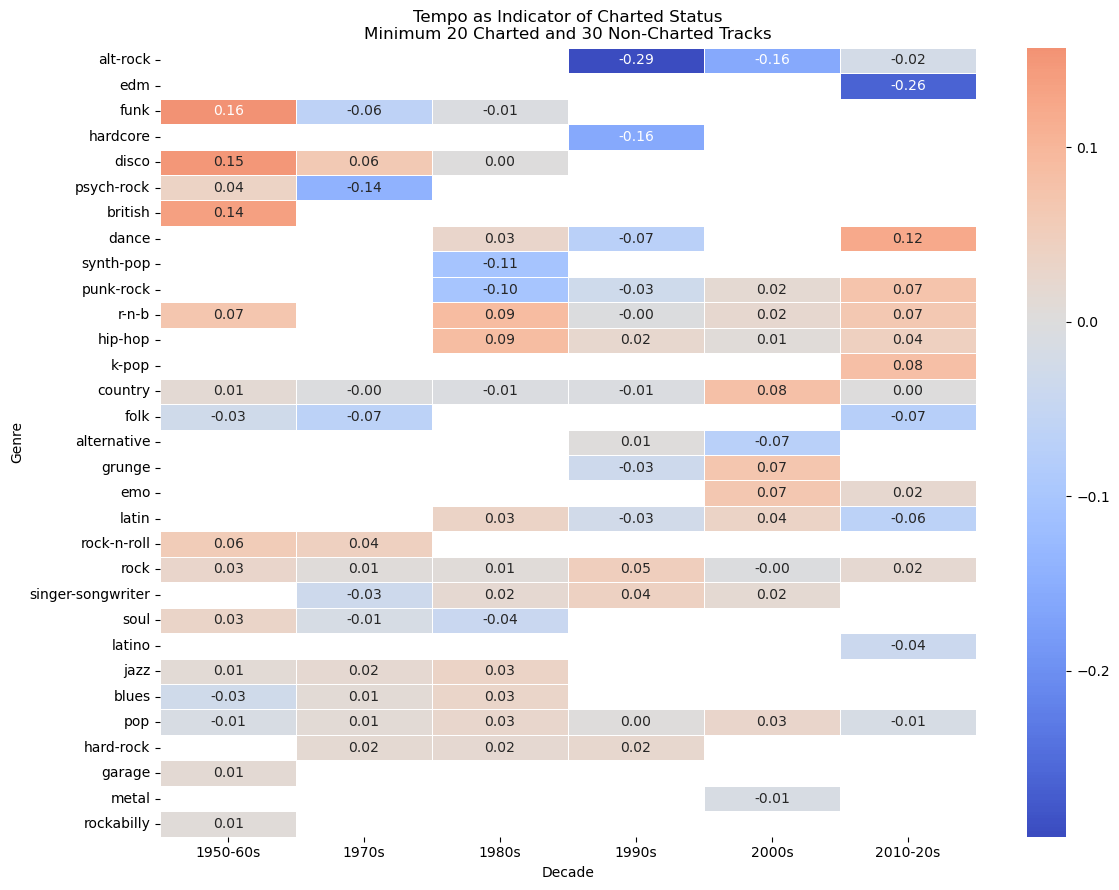

In [264]:

min_charted_count = 50
min_non_charted_count = 50

from scipy.stats import pointbiserialr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_charted_count = 20
min_non_charted_count = 30

feature_chart_corr_results = []

for decade in final_df["decade_label"].dropna().unique():
    
    decade_data = final_df[
        final_df["decade_label"] == decade
    ].copy()
    
    for genre in decade_data["track_genre"].dropna().unique():
        
        genre_decade_data = decade_data[
            decade_data["track_genre"] == genre
        ].copy()
        
        class_counts = genre_decade_data["charted_binary"].value_counts()
        
        charted_count = class_counts.get(1, 0)
        non_charted_count = class_counts.get(0, 0)
        
        # Require at least 20 charted and 30 non-charted tracks
        if charted_count < min_charted_count:
            continue
        
        if non_charted_count < min_non_charted_count:
            continue
        
        for feature in selected_features:
            
            temp_df = genre_decade_data[
                [feature, "charted_binary"]
            ].dropna()
            
            class_counts_temp = temp_df["charted_binary"].value_counts()
            
            charted_count_temp = class_counts_temp.get(1, 0)
            non_charted_count_temp = class_counts_temp.get(0, 0)
            
            # Re-check after dropping missing feature values
            if charted_count_temp < min_charted_count:
                continue
            
            if non_charted_count_temp < min_non_charted_count:
                continue
            
            corr, p_value = pointbiserialr(
                temp_df["charted_binary"],
                temp_df[feature]
            )
            
            feature_chart_corr_results.append({
                "decade_label": decade,
                "track_genre": genre,
                "feature": feature,
                "correlation": corr,
                "p_value": p_value,
                "sample_size": len(temp_df),
                "charted_count": charted_count_temp,
                "non_charted_count": non_charted_count_temp
            })

feature_chart_corr_df = pd.DataFrame(feature_chart_corr_results)

feature_chart_corr_df["correlation"] = (
    feature_chart_corr_df["correlation"].round(3)
)

feature_chart_corr_df["p_value"] = (
    feature_chart_corr_df["p_value"].round(5)
)

feature_chart_corr_df.head()

for selected_feature in selected_features:
    
    feature_corr = feature_chart_corr_df[
        feature_chart_corr_df["feature"] == selected_feature
    ].copy()
    
    corr_pivot = feature_corr.pivot_table(
        index="track_genre",
        columns="decade_label",
        values="correlation"
    )
    
    if corr_pivot.empty:
        continue
    
    corr_pivot = corr_pivot.loc[
        corr_pivot.abs().max(axis=1).sort_values(ascending=False).index
    ]
    
    plt.figure(figsize=(12, 9))
    
    sns.heatmap(
        corr_pivot,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    
    plt.title(
        f"{selected_feature.capitalize()} as Indicator of Charted Status\n"
        f"Minimum {min_charted_count} Charted and {min_non_charted_count} Non-Charted Tracks"
    )
    plt.xlabel("Decade")
    plt.ylabel("Genre")
    
    plt.tight_layout()
    plt.show()

In [ ]:
## Appendix D - Heatmap of correlation to obtaining high CSS score for each feature separately, for each genre per decade (with sample of at least 50 chart tracks) 

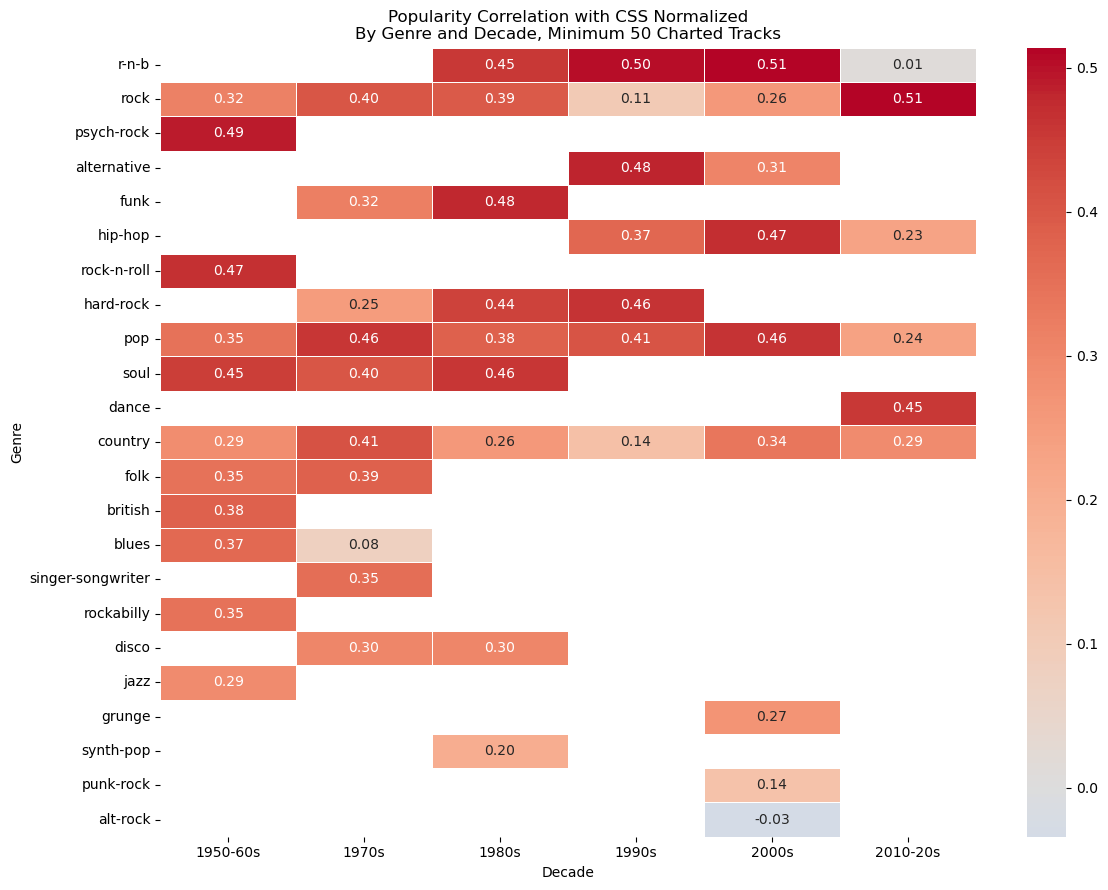

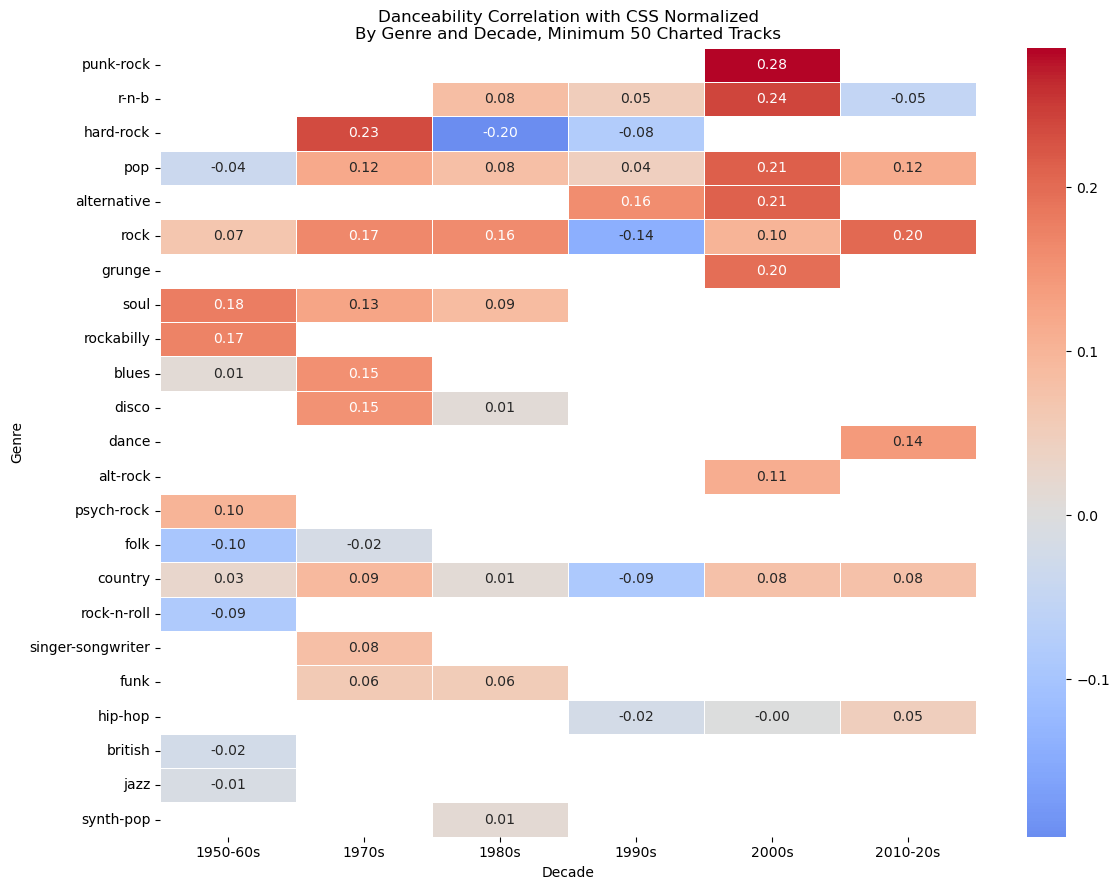

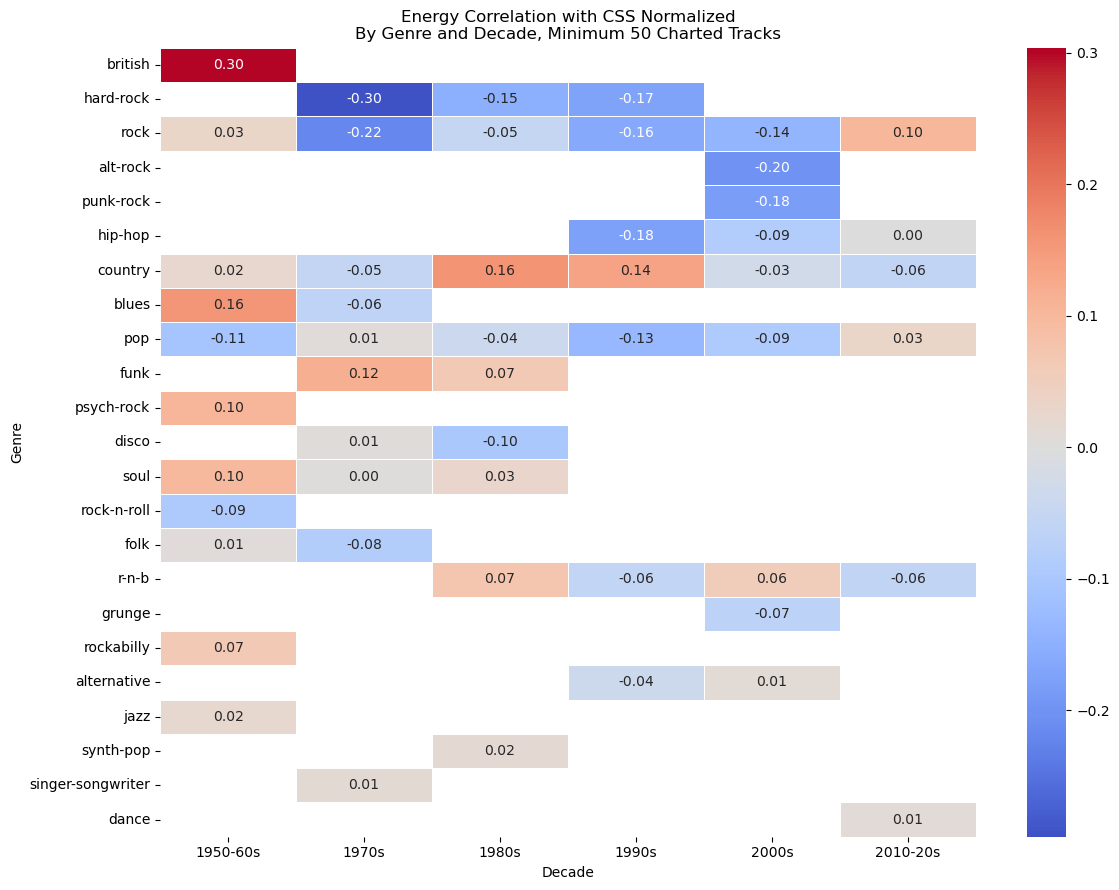

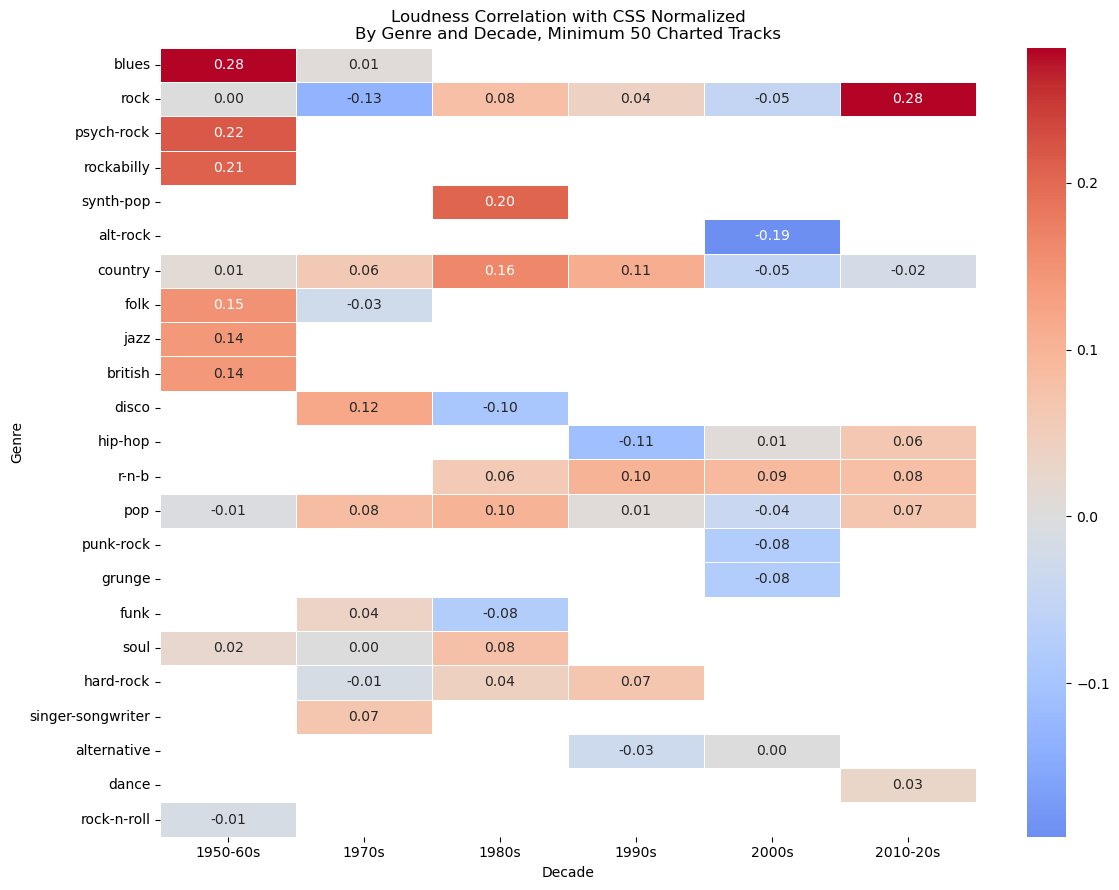

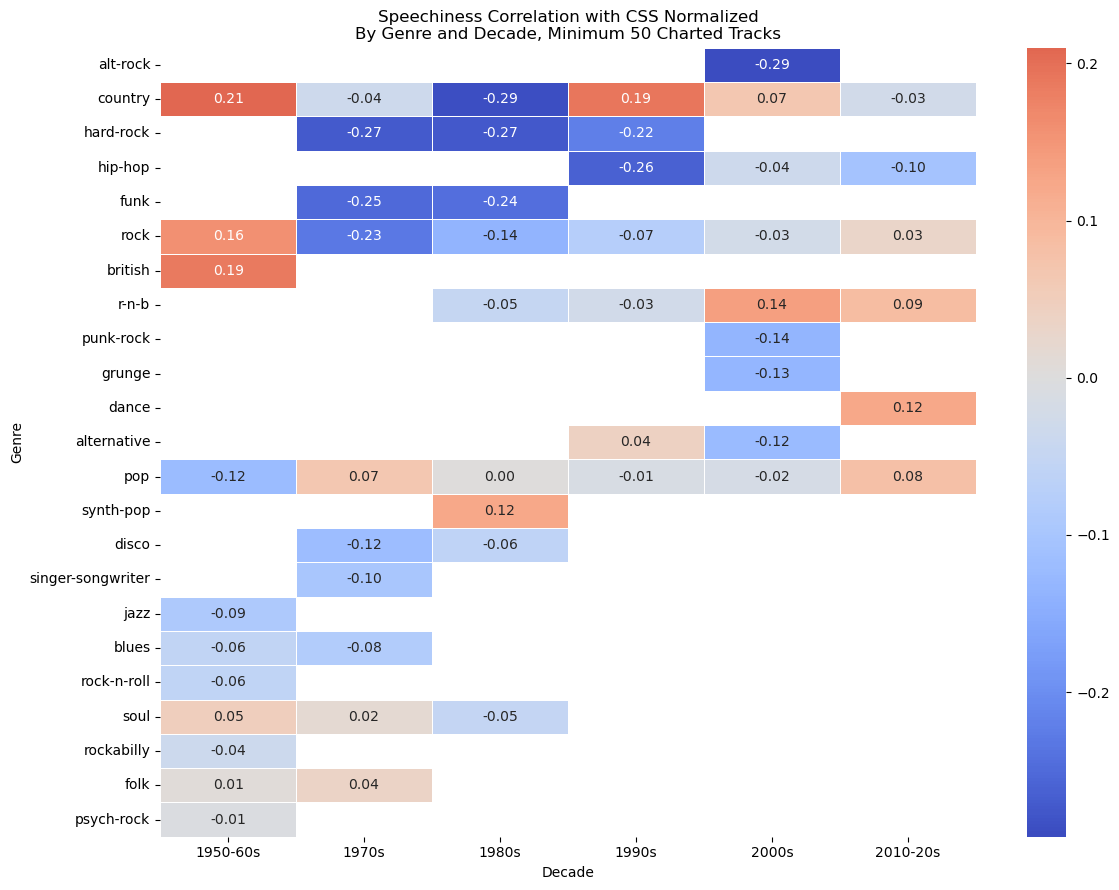

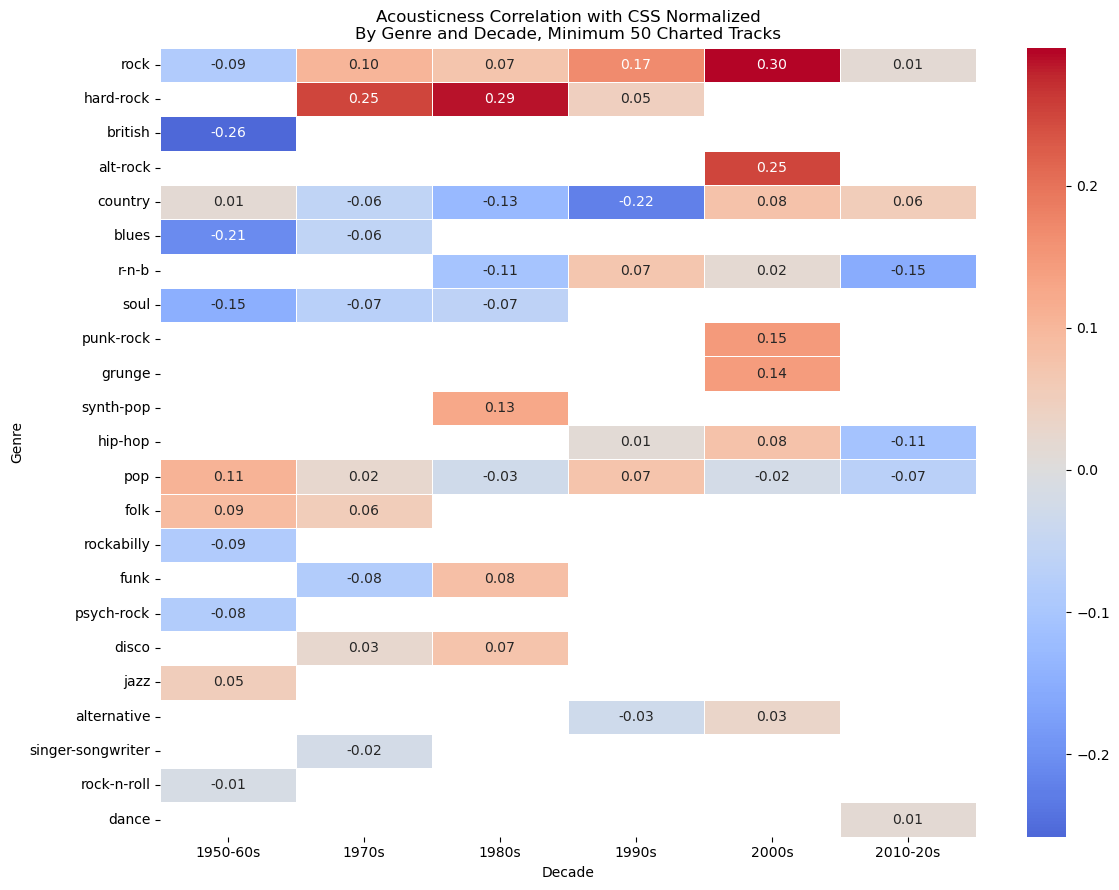

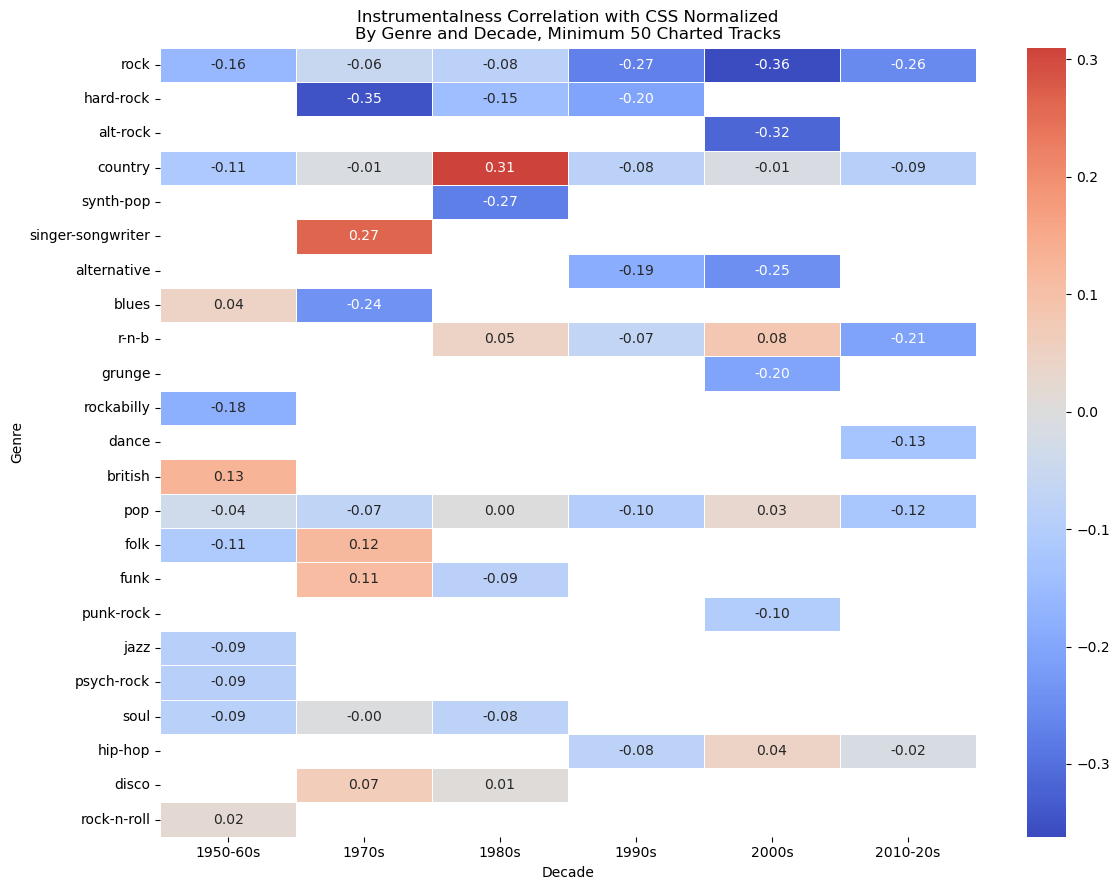

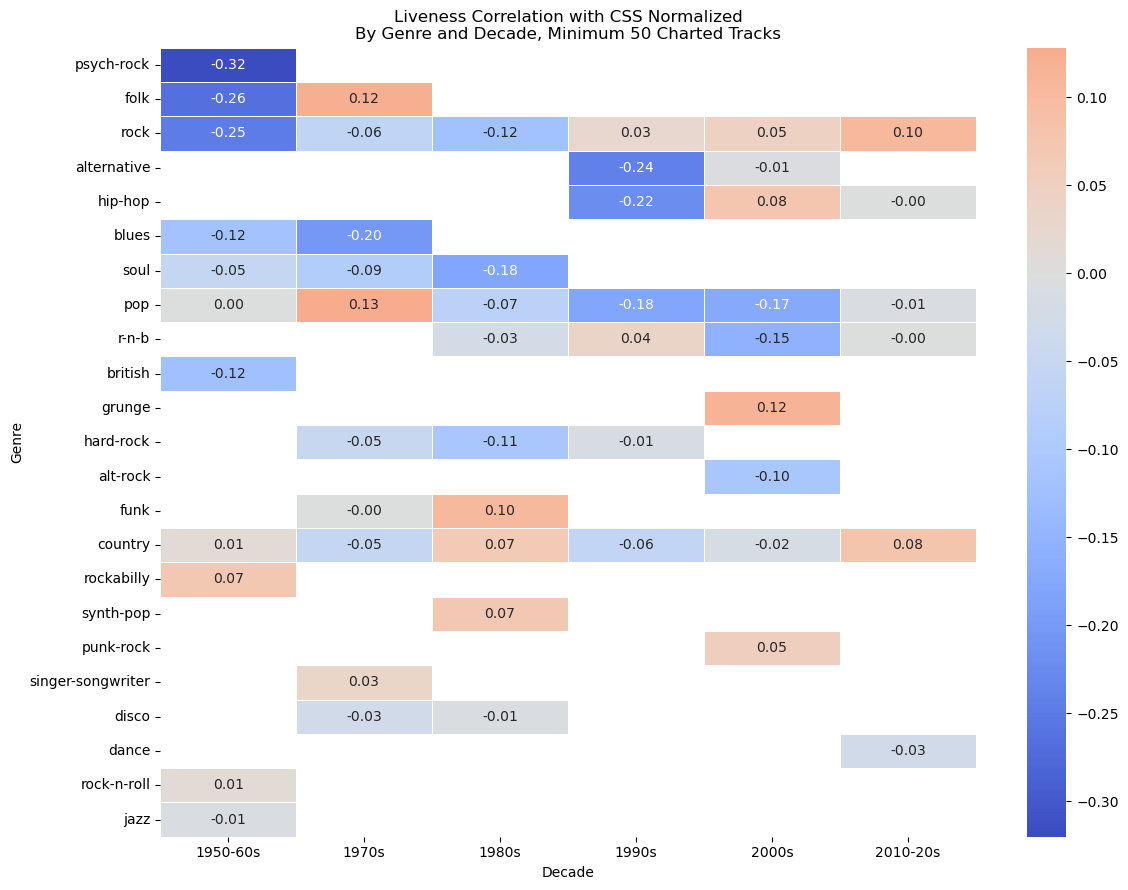

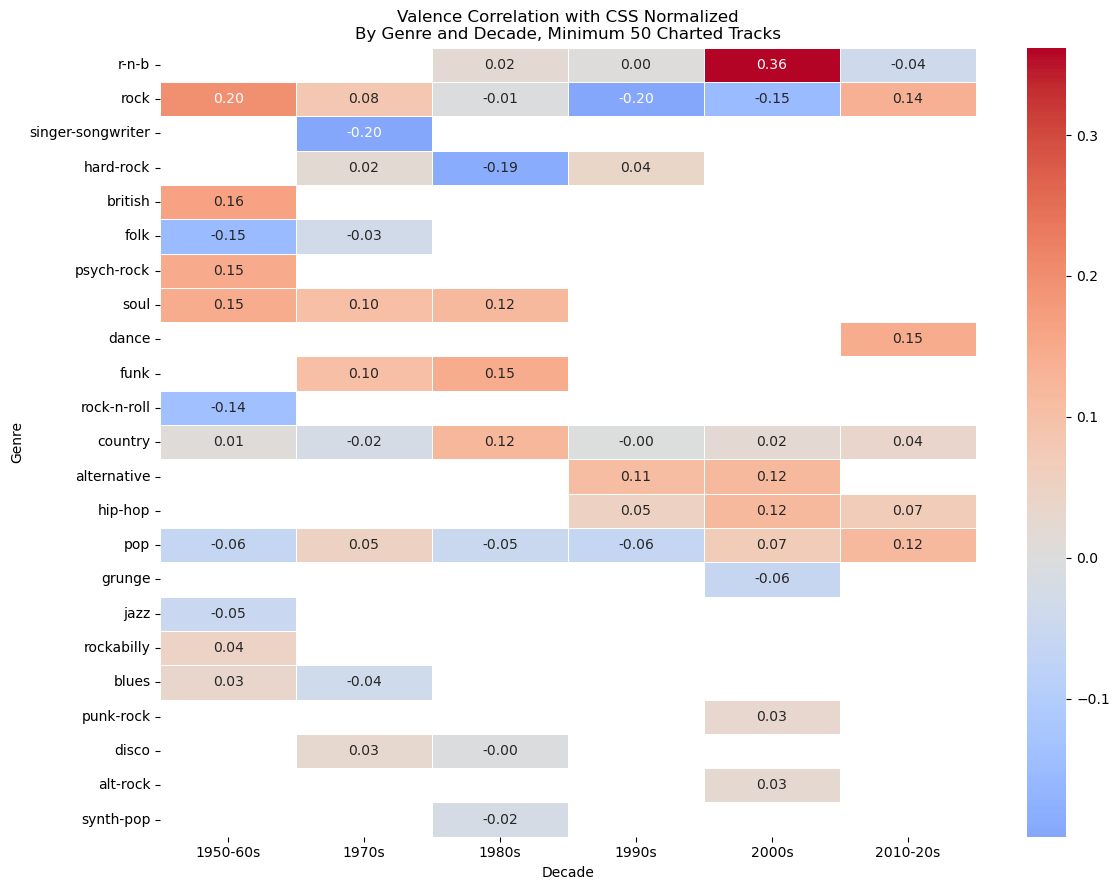

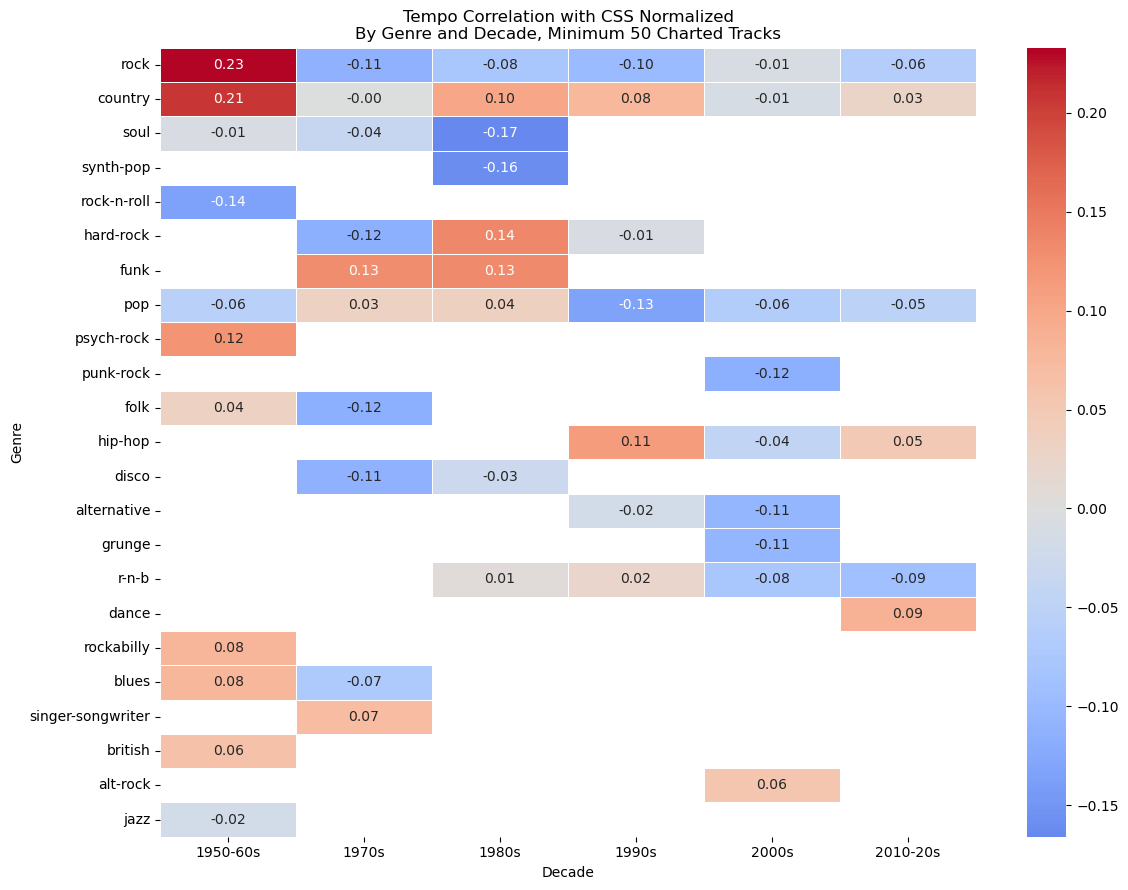

In [263]:


selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_charted_tracks = 50

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

charted_df = charted_df.dropna(
    subset=["decade_label", "track_genre", "CSS_normalized"]
)

charted_df.shape

feature_css_corr_results = []

for decade in charted_df["decade_label"].dropna().unique():
    
    decade_data = charted_df[
        charted_df["decade_label"] == decade
    ].copy()
    
    for genre in decade_data["track_genre"].dropna().unique():
        
        genre_decade_data = decade_data[
            decade_data["track_genre"] == genre
        ].copy()
        
        # Require at least 50 charted tracks in this genre-decade group
        if len(genre_decade_data) < min_charted_tracks:
            continue
        
        for feature in selected_features:
            
            temp_df = genre_decade_data[
                [feature, "CSS_normalized"]
            ].dropna()
            
            # Re-check after dropping missing values
            if len(temp_df) < min_charted_tracks:
                continue
            
            # Spearman needs variation in both columns
            if temp_df[feature].nunique() < 2:
                continue
            
            if temp_df["CSS_normalized"].nunique() < 2:
                continue
            
            corr, p_value = spearmanr(
                temp_df[feature],
                temp_df["CSS_normalized"]
            )
            
            feature_css_corr_results.append({
                "decade_label": decade,
                "track_genre": genre,
                "feature": feature,
                "correlation": corr,
                "p_value": p_value,
                "sample_size": len(temp_df)
            })

feature_css_corr_df = pd.DataFrame(feature_css_corr_results)

feature_css_corr_df["correlation"] = (
    feature_css_corr_df["correlation"].round(3)
)

feature_css_corr_df["p_value"] = (
    feature_css_corr_df["p_value"].round(5)
)

for selected_feature in selected_features:
    
    feature_corr = feature_css_corr_df[
        feature_css_corr_df["feature"] == selected_feature
    ].copy()
    
    corr_pivot = feature_corr.pivot_table(
        index="track_genre",
        columns="decade_label",
        values="correlation"
    )
    
    if corr_pivot.empty:
        continue
    
    # Sort genres by strongest absolute correlation
    corr_pivot = corr_pivot.loc[
        corr_pivot.abs().max(axis=1).sort_values(ascending=False).index
    ]
    
    plt.figure(figsize=(12, 9))
    
    sns.heatmap(
        corr_pivot,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    
    plt.title(
        f"{selected_feature.capitalize()} Correlation with CSS Normalized\n"
        f"By Genre and Decade, Minimum {min_charted_tracks} Charted Tracks"
    )
    plt.xlabel("Decade")
    plt.ylabel("Genre")
    
    plt.tight_layout()
    plt.show()